In [ ]:
import pandas as pd
df=pd.read_csv('eurusd_cleaned.csv')

In [ ]:
df

,Timestamp,Open,High,Low,Close,Volume,Upper Bound,Lower Bound
0,2000-05-30 17:27:00,0.93020,0.93020,0.93020,0.93020,0,1.629435,0.795475
1,2000-05-31 00:50:00,0.93150,0.93150,0.93150,0.93150,0,1.629435,0.795475
2,2000-05-31 00:51:00,0.93150,0.93150,0.93150,0.93150,0,1.629435,0.795475
3,2000-05-31 00:55:00,0.93170,0.93170,0.93170,0.93170,0,1.629435,0.795475
4,2000-05-31 01:01:00,0.93180,0.93180,0.93180,0.93180,0,1.629435,0.795475
...,...,...,...,...,...,...,...,...
7976346,2023-12-29 16:54:00,1.10388,1.10390,1.10387,1.10388,0,1.629435,0.795475
7976347,2023-12-29 16:55:00,1.10389,1.10395,1.10387,1.10395,0,1.629435,0.795475
7976348,2023-12-29 16:56:00,1.10394,1.10394,1.10367,1.10370,0,1.629435,0.795475
7976349,2023-12-29 16:57:00,1.10366,1.10366,1.10366,1.10366,0,1.629435,0.795475


In [ ]:
import pandas as pd

# CSV dosyasını yükle
file_path = 'eurusd_cleaned.csv'  # Dosyanızın tam yolunu belirtin
df = pd.read_csv(file_path)

df['Timestamp'] = pd.to_datetime(df['Timestamp'])

df.set_index('Timestamp', inplace=True)

df_resampled = df.resample('10T').agg({
    'Open': 'first',               # İlk değer
    'High': 'max',                 # Maksimum değer
    'Low': 'min',                  # Minimum değer
    'Close': 'last',               # Son değer
                 # Son değer
})

# Resample edilen veri çerçevesinde eksik (NaN) değerleri kontrol edin ve temizleyin
df_resampled.dropna(inplace=True)

# Sonuçları yazdır
print(df_resampled.head())

# Resample edilmiş veriyi bir CSV dosyasına kaydedin
output_path = 'resampled_5min_data.csv'
df_resampled.to_csv(output_path)

print(f"Resample edilmiş veri başarıyla kaydedildi: {output_path}")


<ipython-input-3-33ce3054cda2>:11: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_resampled = df.resample('10T').agg({


                       Open    High     Low   Close
Timestamp                                          
2000-05-30 17:20:00  0.9302  0.9302  0.9302  0.9302
2000-05-31 00:50:00  0.9315  0.9317  0.9315  0.9317
2000-05-31 01:00:00  0.9318  0.9319  0.9317  0.9319
2000-05-31 01:10:00  0.9321  0.9322  0.9321  0.9322
2000-05-31 01:30:00  0.9317  0.9317  0.9311  0.9311
Resample edilmiş veri başarıyla kaydedildi: resampled_5min_data.csv


In [ ]:
df=df_resampled

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

if 'Timestamp' not in df.columns:
    df['Timestamp'] = pd.to_datetime(df.index)

# Kapanış fiyatlarına dayalı SMA ve EMA hesaplamaları
df['SMA_10'] = df['Close'].rolling(window=10).mean()  # 10 dönemlik Basit Hareketli Ortalama (SMA)
df['SMA_50'] = df['Close'].rolling(window=50).mean()  # 50 dönemlik Basit Hareketli Ortalama (SMA)
df['EMA_10'] = df['Close'].ewm(span=10, adjust=False).mean()  # 10 dönemlik Üstel Hareketli Ortalama (EMA)
df['EMA_50'] = df['Close'].ewm(span=5760, adjust=False).mean()  # 50 dönemlik Üstel Hareketli Ortalama (EMA)

# Bollinger Bands hesaplaması (20 günlük SMA ve 2 standart sapma)
df['20_SMA'] = df['Close'].rolling(window=23040).mean()
df['stddev'] = df['Close'].rolling(window=23040).std()
df['Upper_Band'] = df['20_SMA'] + (2 * df['stddev'])
df['Lower_Band'] = df['20_SMA'] - (2 * df['stddev'])

# RSI hesaplaması
def calculate_rsi(df, column='Close', period=14):
    delta = df[column].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    avg_gain = gain.rolling(window=period, min_periods=1).mean()
    avg_loss = loss.rolling(window=period, min_periods=1).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['RSI'] = calculate_rsi(df, period=14)

# MACD hesaplaması
def calculate_ema(df, column='Close', period=14):
    return df[column].ewm(span=period, adjust=False).mean()

def calculate_macd(df, column='Close'):
    ema_12 = calculate_ema(df, column, period=12)
    ema_26 = calculate_ema(df, column, period=26)
    df['MACD'] = ema_12 - ema_26
    df['MACD_signal'] = calculate_ema(df, column='MACD', period=9)
    df['MACD_hist'] = df['MACD'] - df['MACD_signal']

calculate_macd(df, column='Close')

# ATR hesaplaması
def calculate_atr(df, period=14):
    df['H-L'] = df['High'] - df['Low']
    df['H-PC'] = abs(df['High'] - df['Close'].shift(1))
    df['L-PC'] = abs(df['Low'] - df['Close'].shift(1))
    df['TR'] = df[['H-L', 'H-PC', 'L-PC']].max(axis=1)
    df['ATR'] = df['TR'].rolling(window=period).mean()
    return df

df = calculate_atr(df, period=14)

# Stochastic Oscillator hesaplaması
def calculate_stochastic_oscillator(df, column='Close', period=14):
    df['Lowest_Low'] = df['Low'].rolling(window=period).min()
    df['Highest_High'] = df['High'].rolling(window=period).max()
    df['%K'] = ((df[column] - df['Lowest_Low']) / (df['Highest_High'] - df['Lowest_Low'])) * 100
    df['%D'] = df['%K'].rolling(window=3).mean()  # %D değeri, %K'nın hareketli ortalaması
    return df

df = calculate_stochastic_oscillator(df, column='Close', period=14)

# Fibonacci Retracement hesaplaması
def calculate_fibonacci_retracement(df, column='Close', period=5760):
    df['Highest_Close'] = df[column].rolling(window=period).max()
    df['Lowest_Close'] = df[column].rolling(window=period).min()

    df['Fibo_23.6'] = df['Highest_Close'] - (df['Highest_Close'] - df['Lowest_Close']) * 0.236
    df['Fibo_38.2'] = df['Highest_Close'] - (df['Highest_Close'] - df['Lowest_Close']) * 0.382
    df['Fibo_50.0'] = df['Highest_Close'] - (df['Highest_Close'] - df['Lowest_Close']) * 0.500
    df['Fibo_61.8'] = df['Highest_Close'] - (df['Highest_Close'] - df['Lowest_Close']) * 0.618
    df['Fibo_76.4'] = df['Highest_Close'] - (df['Highest_Close'] - df['Lowest_Close']) * 0.764
    return df

df = calculate_fibonacci_retracement(df, column='Close', period=5760)

df.drop(columns=['H-L', 'H-PC', 'L-PC'], inplace=True)
df.dropna(inplace=True)

df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.set_index('Timestamp', inplace=True)

print(df.head())
print(f"Veri setinin boyutu: {df.shape}")


                       Open    High     Low   Close   SMA_10    SMA_50  \
Timestamp                                                                
2001-02-07 12:00:00  0.9333  0.9336  0.9330  0.9330  0.93280  0.931844   
2001-02-07 12:10:00  0.9331  0.9335  0.9329  0.9335  0.93280  0.931970   
2001-02-07 12:20:00  0.9336  0.9344  0.9335  0.9336  0.93285  0.932112   
2001-02-07 12:30:00  0.9337  0.9352  0.9336  0.9345  0.93306  0.932268   
2001-02-07 12:40:00  0.9343  0.9344  0.9337  0.9339  0.93319  0.932400   

                       EMA_10    EMA_50   20_SMA    stddev  ...  Highest_High  \
Timestamp                                                   ...                 
2001-02-07 12:00:00  0.932873  0.915619  0.90052  0.037832  ...        0.9345   
2001-02-07 12:10:00  0.932987  0.915626  0.90052  0.037832  ...        0.9338   
2001-02-07 12:20:00  0.933098  0.915632  0.90052  0.037832  ...        0.9344   
2001-02-07 12:30:00  0.933353  0.915638  0.90052  0.037832  ...        0.935

In [ ]:
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=9e7c77d4cdc3bbe0873a1d0178054e62d05585067ce60d76d13bd3f131808b86
  Stored in directory: /root/.cache/pip/wheels/a1/d7/29/7781cc5eb9a3659d032d7d15bdd0f49d07d2b24fec29f44bc4
Successfully built ta


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

import ta  # teknik analiz indikatörleri
from xgboost import XGBRegressor




In [ ]:
 df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

In [ ]:
    df["Stoch_k"] = ta.momentum.stoch(high=df["High"],
                                       low=df["Low"],
                                       close=df["Close"],
                                       window=14,
                                       smooth_window=3)
    df["Stoch_d"] = ta.momentum.stoch_signal(high=df["High"],
                                              low=df["Low"],
                                              close=df["Close"],
                                              window=14,
                                              smooth_window=3)

    df["log_return_lag1"] = df["log_return"].shift(1)
    df["log_return_lag2"] = df["log_return"].shift(2)
    df["log_return_lag3"] = df["log_return"].shift(3)

In [ ]:
import pandas as pd
import numpy as np

df['Momentum'] = df['Close'] - df['Close'].shift(10)
df['Williams_R'] = (df['High'].rolling(14).max() - df['Close']) / (df['High'].rolling(14).max() - df['Low'].rolling(14).min()) * -100
df['Cumulative_Log_Return'] = df['log_return'].cumsum()
df['Exponential_Weighted_Log_Return'] = df['log_return'].ewm(span=10, adjust=False).mean()
df['Bollinger_Bandwidth'] = (df['Upper_Band'] - df['Lower_Band']) / df['20_SMA']
df['Historical_Volatility'] = df['log_return'].rolling(window=10).std()
df['Drawdown'] = (df['Close'].cummax() - df['Close']) / df['Close'].cummax()


In [ ]:
df['Volatility_EURUSD'] = df['Close'].rolling(window=30).std()
df['Volatility_CHFUSD'] = df['Close_CHF'].rolling(window=30).std()
df['Volatility_GBPUSD'] = df['Close_GBP'].rolling(window=30).std()
df['Volatility_GBPEUR'] = df['Close_GBP2'].rolling(window=30).std()
df['Volatility_CHFEUR'] = df['Close_CHF2'].rolling(window=30).std()


KeyError: 'Close_CHF'

In [ ]:
df['Volatility_EURUSD'] = df['Close'].rolling(window=30).std()


In [ ]:
df['Momentum'] = df['Close'] - df['Close'].shift(14)
df['ROC'] = (df['Close'] - df['Close'].shift(14)) / df['Close'].shift(14)
df['Z_Score'] = (df['Close'] - df['Close'].rolling(20).mean()) / df['Close'].rolling(20).std()
df['Rel_High_Low'] = (df['High'] - df['Low']) / df['Close']

In [ ]:
import ta
df['ADX'] = ta.trend.adx(df['High'], df['Low'], df['Close'], window=14)
def calculate_tema(series, window):
    # İlk EMA
    ema1 = series.ewm(span=window, adjust=False).mean()
    # İkinci EMA
    ema2 = ema1.ewm(span=window, adjust=False).mean()
    # Üçüncü EMA
    ema3 = ema2.ewm(span=window, adjust=False).mean()
    # TEMA Hesaplama
    tema = (3 * ema1) - (3 * ema2) + ema3
    return tema

# TEMA Hesaplama
df['Donchian_High'] = df['High'].rolling(window=20).max()
df['Donchian_Low'] = df['Low'].rolling(window=20).min()
df['VI_Positive'] = ta.trend.vortex_indicator_pos(df['High'], df['Low'], df['Close'], window=14)
df['VI_Negative'] = ta.trend.vortex_indicator_neg(df['High'], df['Low'], df['Close'], window=14)
df['HV'] = df['Close'].pct_change().rolling(window=20).std() * (252**0.5)  # Yıllıklaştırılmış volatilite
df['Normalized_ATR'] = df['ATR'] / df['Close']
df['Rel_Close_Open'] = (df['Close'] - df['Open']) / df['Open']
df['Fibo_Ratio'] = (df['Close'] - df['Lowest_Low']) / (df['Highest_High'] - df['Lowest_Low'])


In [ ]:
import ta
df['ADX'] = ta.trend.adx(df['High'], df['Low'], df['Close'], window=14)
def calculate_tema(series, window):
    # İlk EMA
    ema1 = series.ewm(span=window, adjust=False).mean()
    # İkinci EMA
    ema2 = ema1.ewm(span=window, adjust=False).mean()
    # Üçüncü EMA
    ema3 = ema2.ewm(span=window, adjust=False).mean()
    # TEMA Hesaplama
    tema = (3 * ema1) - (3 * ema2) + ema3
    return tema

# TEMA Hesaplama
df['Donchian_High'] = df['High'].rolling(window=20).max()
df['Donchian_Low'] = df['Low'].rolling(window=20).min()
df['VI_Positive'] = ta.trend.vortex_indicator_pos(df['High'], df['Low'], df['Close'], window=14)
df['VI_Negative'] = ta.trend.vortex_indicator_neg(df['High'], df['Low'], df['Close'], window=14)
df['HV'] = df['Close'].pct_change().rolling(window=20).std() * (252**0.5)  # Yıllıklaştırılmış volatilite
df['Normalized_ATR'] = df['ATR'] / df['Close']
df['Rel_Close_Open'] = (df['Close'] - df['Open']) / df['Open']
df['Fibo_Ratio'] = (df['Close'] - df['Lowest_Low']) / (df['Highest_High'] - df['Lowest_Low'])


In [ ]:
df['Hour'] = df.index.hour  # Saat bilgisi
df['DayOfWeek'] = df.index.dayofweek  # Haftanın günü (0=Monday, 6=Sunday)
df['Is_Weekend'] = (df['DayOfWeek'] >= 5).astype(int)  # Hafta sonu mu?
df['Month'] = df.index.month  # Ay bilgisi
df['DayOfMonth'] = df.index.day  # Ayın günü
df['Quarter'] = df.index.quarter  # Yılın hangi çeyreğinde olduğu
df['WeekOfYear'] = df.index.isocalendar().week  # Yılın kaçıncı haftası


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


In [ ]:
# 📌 Veri setini yükle

# 📌 Gereksiz sütunları çıkar
drop_cols = ["Timestamp", "Market_Open", "Weekend", "Time_Diff"]  # Zaman bilgileri & Binary sütunlar
df = df.drop(columns=drop_cols, errors='ignore')

# 📌 Tahmin edilecek hedef değişkeni ekle (1-10 dakika arası horizon)
for horizon in range(1, 11):
    df[f'y_target_{horizon}'] = df['Close'].shift(-horizon)

# 📌 NaN değerleri çıkar
df = df.dropna()

# 📌 Feature Selection (22 özellik seçimi)
selected_features = [
    'Cumulative_Log_Return', 'Drawdown', 'Rel_High_Low', 'Low', 'High',
    'log_return', 'Rel_Close_Open', 'Open', 'EMA_10', 'SMA_10',
    'Fibo_76.4', 'Fibo_23.6', 'Fibo_50.0', 'Normalized_ATR',
    'Volatility_EURUSD', 'ATR', 'MACD', 'MACD_signal',
    'Historical_Volatility', 'Bollinger_Bandwidth',
    'Quarter', 'WeekOfYear',"log_return_lag1", "log_return_lag2",'Hour','DayOfWeek','DayOfMonth','Month'
]

# 📌 Standart ölçekleme (StandardScaler)
scaler = StandardScaler()
df[selected_features] = scaler.fit_transform(df[selected_features])

# 📌 Eğitim, doğrulama ve test setlerini ayır
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)
test_size = len(df) - train_size - val_size

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size + val_size]
test_df = df.iloc[train_size + val_size:]

print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")


Train: 582152, Validation: 124746, Test: 124748


In [ ]:
import numpy as np
import os

# 📌 NumPy memmap ile veriyi disk tabanlı işleme
memmap_file = "tft_data.npy"

# Eğer dosya yoksa oluştur
if not os.path.exists(memmap_file):
    data_array = df[selected_features].values
    np.save(memmap_file, data_array)

# Memmap ile yükleme
data_memmap = np.load(memmap_file, mmap_mode='r')

# 📌 Memmap'e dayalı PyTorch Dataset oluştur
class MemmapDataset(torch.utils.data.Dataset):
    def __init__(self, memmap_array, target_array, sequence_length=60):
        self.memmap_array = memmap_array
        self.target_array = target_array
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.memmap_array) - self.sequence_length

    def __getitem__(self, idx):
        temporal = self.memmap_array[idx:idx + self.sequence_length]  # NumPy memmap array
        target = self.target_array[idx + self.sequence_length]  # Hedef değer

        # 📌 Hata düzeltildi: NumPy memmap dizisine `expand_dims()` uyguluyoruz
        temporal = np.expand_dims(temporal, axis=-2)  # (seq_len, num_vars=1, num_features)

        return torch.tensor(temporal, dtype=torch.float32), \
               torch.tensor(target, dtype=torch.float32)



# 📌 Target değişkeni (y_target_1 seçildi, isteğe göre değiştirilebilir)
target_memmap = df['y_target_1'].values

# 📌 Memmap Dataset ve DataLoader
train_dataset = MemmapDataset(data_memmap[:train_size], target_memmap[:train_size])
val_dataset = MemmapDataset(data_memmap[train_size:train_size + val_size], target_memmap[train_size:train_size + val_size])
test_dataset = MemmapDataset(data_memmap[train_size + val_size:], target_memmap[train_size + val_size:])

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Memmap Train: {len(train_dataset)}, Validation: {len(val_dataset)}, Test: {len(test_dataset)}")


Memmap Train: 582092, Validation: 124686, Test: 124688


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class VariableSelectionNetwork(nn.Module):
    """
    Variable Selection Network for feature-wise processing
    """
    def __init__(self, num_vars, hidden_dim, dropout=0.1):
        super().__init__()
        self.num_vars = num_vars
        self.hidden_dim = hidden_dim

        # GRU context generator for temporal dynamics
        self.context_gen = nn.GRU(input_size=hidden_dim, hidden_size=hidden_dim, batch_first=True)

        # Feature selection weights
        self.weight_net = nn.Sequential(
            nn.Linear(hidden_dim * 2, num_vars),
            nn.Softmax(dim=-1)
        )

        # **📌 Burayı Güncelledik: Her değişkeni 64 boyutuna dönüştür**
        self.feature_transforms = nn.ModuleList([
            nn.Linear(28, hidden_dim) for _ in range(num_vars)  # ❌ 28 → ✅ hidden_dim (64)
        ])

        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim)

    def forward(self, x, static_context=None):
        batch_size, seq_len, num_vars, _ = x.shape

        # Generate context
        if static_context is not None:
            context = static_context.unsqueeze(1).expand(-1, seq_len, -1)
        else:
            context, _ = self.context_gen(x.flatten(0, 1))
            context = context.view(batch_size, seq_len, -1)

        # Compute selection weights
        weights = self.weight_net(torch.cat([x.mean(dim=2), context], dim=-1))
        weights = self.dropout(weights)

        # **📌 Özellikleri 64 boyutuna dönüştür**
        transformed = torch.stack([
            trans(x[..., i, :]) for i, trans in enumerate(self.feature_transforms)
        ], dim=-2)  # (B, T, num_vars, hidden_dim)

        # **📌 Çıkış boyutunu zorla!**
        transformed = transformed.view(batch_size, seq_len, -1, self.hidden_dim)

        # **📌 Boyutları kontrol et**
        print(f"📌 Transformed Feature Shape: {transformed.shape}")
        assert transformed.shape[-1] == self.hidden_dim, "Feature transform output boyutu hatalı!"

        # Apply feature selection
        weighted = transformed * weights.unsqueeze(-1)
        selected = weighted.sum(dim=-2)

        # **📌 Son boyutu tekrar kontrol et**
        print(f"📌 Final Output Shape: {selected.shape}")
        assert selected.shape[-1] == self.hidden_dim, "VariableSelectionNetwork çıkış boyutu yanlış!"

        return self.layer_norm(selected)




class GatedResidualNetwork(nn.Module):
    """
    Enhanced GRN with GLU gating and residual connections
    Implements the full gating mechanism from the TFT paper
    """
    def __init__(self, input_dim, hidden_dim, output_dim=None, dropout=0.1):
        super().__init__()
        output_dim = output_dim or input_dim
        self.hidden_dim = hidden_dim

        # GLU Gating mechanism
        self.gate = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GLU(dim=-1),
            nn.Dropout(dropout)
        )

        # Main layers
        self.dense = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.Dropout(dropout)
        )

        # Residual processing
        self.residual = nn.Linear(input_dim, output_dim) if input_dim != output_dim else nn.Identity()
        self.layer_norm = nn.LayerNorm(output_dim)

    def forward(self, x):
        # Gated transformation
        gate = self.gate(x)
        transformed = self.dense(x)

        # Residual connection
        output = self.layer_norm(transformed * gate + self.residual(x))
        return output

class TemporalSelfAttention(nn.Module):
    """
    Enhanced Temporal Attention with position encoding, layer norms,
    and residual connections as per TFT specifications
    """
    def __init__(self, hidden_dim, n_heads, dropout=0.1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_heads = n_heads

        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)

        self.pos_encoder = PositionalEncoding(hidden_dim, dropout)
        self.attn_dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim)

        # Final dense layer
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim*2),
            nn.GELU(),
            nn.Linear(hidden_dim*2, hidden_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x, mask=None):
        residual = x
        x = self.layer_norm(x + self.pos_encoder(x))

        # Multi-head attention
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        attn_output, _ = F._scaled_dot_product_attention(
            q, k, v, attn_mask=mask, dropout_p=self.attn_dropout.p if self.training else 0
        )

        # Final processing
        output = self.fc(attn_output)
        return self.layer_norm(output + residual)

class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding for temporal sequences"""
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))

        pe = torch.zeros(1, max_len, d_model)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class DynamicAttentionHeads(nn.Module):
    """
    Enhanced Dynamic Attention with learnable gating mechanism
    Combines multiple attention heads with adaptive weighting
    """
    def __init__(self, hidden_dim, n_heads, dropout=0.1):
        super().__init__()
        self.heads = nn.ModuleList([
            TemporalSelfAttention(hidden_dim, n_heads=1, dropout=dropout)
            for _ in range(n_heads)
        ])

        # Learnable gate weights
        self.gate = nn.Sequential(
            nn.Linear(hidden_dim * n_heads, n_heads),
            nn.Softmax(dim=-1)
        )

        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.residual = nn.Linear(hidden_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        residual = self.residual(x)
        outputs = [head(x) for head in self.heads]
        stacked = torch.stack(outputs, dim=-1)  # [B, T, D, H]

        # Compute gate weights
        gate_weights = self.gate(stacked.flatten(start_dim=-2))
        combined = (stacked * gate_weights.unsqueeze(-2)).sum(dim=-1)

        return self.layer_norm(combined + residual)

class NoisyLinear(nn.Module):
    """
    Noisy Linear Layer with factorized noise as in NoisyNet
    Reduces computation by using factorized Gaussian noise
    """
    def __init__(self, in_features, out_features, sigma_init=0.017):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.sigma_init = sigma_init

        # Learnable parameters
        self.weight_mu = nn.Parameter(torch.Tensor(out_features, in_features))
        self.weight_sigma = nn.Parameter(torch.Tensor(out_features, in_features))
        self.register_buffer('weight_epsilon', torch.Tensor(out_features, in_features))

        self.bias_mu = nn.Parameter(torch.Tensor(out_features))
        self.bias_sigma = nn.Parameter(torch.Tensor(out_features))
        self.register_buffer('bias_epsilon', torch.Tensor(out_features))

        self.reset_parameters()
        self.reset_noise()

    def reset_parameters(self):
        mu_range = 1 / math.sqrt(self.in_features)
        self.weight_mu.data.uniform_(-mu_range, mu_range)
        self.weight_sigma.data.fill_(self.sigma_init)
        self.bias_mu.data.uniform_(-mu_range, mu_range)
        self.bias_sigma.data.fill_(self.sigma_init)

    def _scale_noise(self, size):
        x = torch.randn(size)
        return x.sign().mul_(x.abs().sqrt_())

    def reset_noise(self):
        epsilon_in = self._scale_noise(self.in_features)
        epsilon_out = self._scale_noise(self.out_features)

        self.weight_epsilon.copy_(epsilon_out.ger(epsilon_in))
        self.bias_epsilon.copy_(epsilon_out)

    def forward(self, x):
        if self.training:
            weight = self.weight_mu + self.weight_sigma * self.weight_epsilon
            bias = self.bias_mu + self.bias_sigma * self.bias_epsilon
        else:
            weight = self.weight_mu
            bias = self.bias_mu

        return F.linear(x, weight, bias)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR

# ---------------------------------------------------------------------------
# Dynamic Attention Heads
# ---------------------------------------------------------------------------
class DynamicAttentionHeads(nn.Module):
    def __init__(self, input_dim, attention_heads):
        super().__init__()
        self.attention_heads = attention_heads
        self.head_weights = nn.Linear(input_dim, attention_heads)

    def forward(self, x):
        batch_size, seq_len, features = x.shape
        # Özellik sayısının (features) attention_heads'e tam bölünebildiğinden emin olun
        assert features % self.attention_heads == 0, (
            f"Features {features} must be divisible by attention_heads {self.attention_heads}"
        )
        # Zaman serisi ortalaması üzerinden her head için ağırlıkları hesapla
        head_importance = torch.softmax(self.head_weights(x.mean(dim=1)), dim=-1)  # (batch, heads)
        head_importance = head_importance.view(batch_size, 1, self.attention_heads, 1)
        # Özellikleri attention head'lere ayır
        x_grouped = x.view(batch_size, seq_len, self.attention_heads, features // self.attention_heads)
        # Ağırlıklı temsil
        x_weighted = x_grouped * head_importance
        # Tekrar birleşik hale getir
        return x_weighted.view(batch_size, seq_len, features)

# ---------------------------------------------------------------------------
# Gated Residual Network (GRN)
# ---------------------------------------------------------------------------
class GatedResidualNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim=None, dropout=0.1):
        super().__init__()
        hidden_dim = hidden_dim or input_dim

        self.dense = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.gate = nn.Linear(hidden_dim, hidden_dim, bias=False)
        # Giriş boyutu hidden_dim'e eşit değilse projeksiyon uygula
        self.proj = nn.Linear(input_dim, hidden_dim) if input_dim != hidden_dim else nn.Identity()

    def forward(self, x, context=None):
        if context is not None:
            x = torch.cat([x, context], dim=-1)
        residual = self.proj(x)
        output = self.dense(x)
        gate = torch.sigmoid(self.gate(output))
        return gate * output + (1 - gate) * residual

# ---------------------------------------------------------------------------
# Variable Selection Network (VSN)
# ---------------------------------------------------------------------------
class VariableSelectionNetwork(nn.Module):
    def __init__(self, num_vars, hidden_dim):
        super().__init__()
        # GRN ile tüm değişkenler arası etkileşimden ağırlıklar hesaplanıyor
        self.weight_grn = GatedResidualNetwork(input_dim=num_vars, hidden_dim=num_vars)
        self.softmax = nn.Softmax(dim=-1)
        # Her bir değişken için hidden boyuta projeksiyon yapan GRN’ler
        self.variable_grns = nn.ModuleList([
            GatedResidualNetwork(input_dim=1, hidden_dim=hidden_dim)
            for _ in range(num_vars)
        ])

    def forward(self, x):
        """
        Args:
            x: (batch, seq_len, num_vars) şeklinde giriş tensörü.
        Returns:
            (batch, seq_len, hidden_dim) boyutunda ağırlıklandırılmış çıktı.
        """
        # Değişken seçimi ağırlıklarını hesapla (global perspektif)
        weights = self.softmax(self.weight_grn(x))  # (batch, seq_len, num_vars)
        # Her değişkenin temsili (individually processed)
        var_embeddings = [
            self.variable_grns[i](x[..., i].unsqueeze(-1))
            for i in range(x.size(-1))
        ]
        # (batch, seq_len, hidden_dim, num_vars)
        var_embeddings = torch.stack(var_embeddings, dim=-1)
        # Ağırlıkları uygulayıp, değişkenler boyunca toplama
        weighted_sum = torch.sum(var_embeddings * weights.unsqueeze(2), dim=-1)  # (batch, seq_len, hidden_dim)
        return weighted_sum

# ---------------------------------------------------------------------------
# Temporal Self-Attention
# ---------------------------------------------------------------------------
class TemporalSelfAttention(nn.Module):
    def __init__(self, input_dim, heads):
        super().__init__()
        assert input_dim % heads == 0, "input_dim must be divisible by num_heads!"
        self.attn = nn.MultiheadAttention(embed_dim=input_dim, num_heads=heads, batch_first=True)

    def forward(self, x):
        seq_len = x.size(1)
        # Nedenselliği sağlamak için causal (üst üçgensel) maske
        mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device), diagonal=1).bool()
        x, _ = self.attn(x, x, x, attn_mask=mask)
        return x

# ---------------------------------------------------------------------------
# Temporal Fusion Transformer (TFT) Modeli - Geliştirilmiş Versiyon
# ---------------------------------------------------------------------------
class TFTModel(nn.Module):
    def __init__(self, num_vars, hidden_dim, num_layers, attention_heads):
        super().__init__()

        # Variable Selection Network: Giriş değişkenlerinin birleşik temsili
        self.vsn = VariableSelectionNetwork(num_vars=num_vars, hidden_dim=hidden_dim)
        # Gated Residual Network ile VSN çıktısını işleme
        self.grn = GatedResidualNetwork(hidden_dim, hidden_dim)
        # Temporal Self-Attention: Yalnızca geçmiş veride uygulanıyor
        self.self_attention = TemporalSelfAttention(hidden_dim, attention_heads)

        # Past LSTM: Bidirectional (geçmiş için iki yönlü)
        self.past_lstm = nn.LSTM(hidden_dim, hidden_dim, num_layers, batch_first=True, bidirectional=True)
        # Future LSTM: Unidirectional (gelecek için nedensellik korunsun)
        self.future_lstm = nn.LSTM(hidden_dim, hidden_dim, num_layers, batch_first=True, bidirectional=False)
        # Gelecek LSTM çıkışını 2*hidden_dim'e çıkarmak için ek projeksiyon
        self.future_projection = nn.Linear(hidden_dim, hidden_dim * 2)

        # Dynamic Attention Heads: Past ve Future LSTM çıktılarını birleştirdikten sonra
        # Birleştirilmiş özellik boyutu: 2*hidden_dim (past) + 2*hidden_dim (future) = 4*hidden_dim
        self.attention_heads = DynamicAttentionHeads(hidden_dim * 4, attention_heads)

        # Son Çıkış Katmanı (NoisyLinear yerine plain Linear kullanıldı)
        self.fc = nn.Linear(hidden_dim * 4, 1)

    def forward(self, past_x, future_x):
        """
        Args:
            past_x: (batch, seq_len, num_vars) şeklinde geçmiş giriş verisi.
            future_x: (batch, seq_len, num_vars) şeklinde geleceğe ait giriş verisi.
        Returns:
            (batch, 1) tahmin çıktısı.
        """
        # Geçmiş verinin işlenmesi
        past_features = self.vsn(past_x)                # (batch, seq_len, hidden_dim)
        past_features = self.grn(past_features)           # (batch, seq_len, hidden_dim)
        past_features = self.self_attention(past_features)  # (batch, seq_len, hidden_dim)

        # Gelecek verinin işlenmesi (self-attention uygulanmıyor)
        future_features = self.vsn(future_x)              # (batch, seq_len, hidden_dim)
        future_features = self.grn(future_features)         # (batch, seq_len, hidden_dim)

        # LSTM İşlemleri
        past_out, _ = self.past_lstm(past_features)       # (batch, seq_len, 2*hidden_dim)
        future_out, _ = self.future_lstm(future_features)   # (batch, seq_len, hidden_dim)
        future_out = self.future_projection(future_out)     # (batch, seq_len, 2*hidden_dim)

        # LSTM çıktılarının özellik boyutunda birleştirilmesi
        combined = torch.cat((past_out, future_out), dim=-1)  # (batch, seq_len, 4*hidden_dim)
        # Dynamic attention uygulaması
        x_attended = self.attention_heads(combined)           # (batch, seq_len, 4*hidden_dim)
        # Son zaman adımının çıktısından tahmin üretiliyor
        output = self.fc(x_attended[:, -1, :])                # (batch, 1)
        return output

# ---------------------------------------------------------------------------
# Model Parametreleri ve Kurulum
# ---------------------------------------------------------------------------
num_vars = 28       # Girişteki değişken sayısı
hidden_dim = 128
num_layers = 2
attention_heads = 4

# Cihaz seçimi: CUDA varsa GPU, aksi halde CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TFTModel(num_vars, hidden_dim, num_layers, attention_heads).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_function = nn.MSELoss()

print("✅ Model başarıyla güncellendi, geliştirmeler eklendi ve optimizasyonlar ayarlandı!")


✅ Model başarıyla güncellendi, geliştirmeler eklendi ve optimizasyonlar ayarlandı!


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR

# ---------------------------------------------------------------------------
# Dynamic Attention Heads
# ---------------------------------------------------------------------------
class DynamicAttentionHeads(nn.Module):
    def __init__(self, input_dim, attention_heads):
        super().__init__()
        self.attention_heads = attention_heads
        self.head_weights = nn.Linear(input_dim, attention_heads)

    def forward(self, x):
        batch_size, seq_len, features = x.shape
        # Özellik sayısının (features) attention_heads'e tam bölünebildiğinden emin olun
        assert features % self.attention_heads == 0, (
            f"Features {features} must be divisible by attention_heads {self.attention_heads}"
        )
        # Zaman serisi ortalaması üzerinden her head için ağırlıkları hesapla
        head_importance = torch.softmax(self.head_weights(x.mean(dim=1)), dim=-1)  # (batch, heads)
        head_importance = head_importance.view(batch_size, 1, self.attention_heads, 1)
        # Özellikleri attention head'lere ayır
        x_grouped = x.view(batch_size, seq_len, self.attention_heads, features // self.attention_heads)
        # Ağırlıklı temsil
        x_weighted = x_grouped * head_importance
        # Tekrar birleşik hale getir
        return x_weighted.view(batch_size, seq_len, features)

# ---------------------------------------------------------------------------
# Gated Residual Network (GRN)
# ---------------------------------------------------------------------------
class GatedResidualNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim=None, dropout=0.1):
        super().__init__()
        hidden_dim = hidden_dim or input_dim

        self.dense = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.gate = nn.Linear(hidden_dim, hidden_dim, bias=False)
        # Giriş boyutu hidden_dim'e eşit değilse projeksiyon uygula
        self.proj = nn.Linear(input_dim, hidden_dim) if input_dim != hidden_dim else nn.Identity()

    def forward(self, x, context=None):
        if context is not None:
            x = torch.cat([x, context], dim=-1)
        residual = self.proj(x)
        output = self.dense(x)
        gate = torch.sigmoid(self.gate(output))
        return gate * output + (1 - gate) * residual

# ---------------------------------------------------------------------------
# Variable Selection Network (VSN)
# ---------------------------------------------------------------------------
class VariableSelectionNetwork(nn.Module):
    def __init__(self, num_vars, hidden_dim):
        super().__init__()
        # GRN ile tüm değişkenler arası etkileşimden ağırlıklar hesaplanıyor
        self.weight_grn = GatedResidualNetwork(input_dim=num_vars, hidden_dim=num_vars)
        self.softmax = nn.Softmax(dim=-1)
        # Her bir değişken için hidden boyuta projeksiyon yapan GRN’ler
        self.variable_grns = nn.ModuleList([
            GatedResidualNetwork(input_dim=1, hidden_dim=hidden_dim)
            for _ in range(num_vars)
        ])

    def forward(self, x):
        """
        Args:
            x: (batch, seq_len, num_vars) şeklinde giriş tensörü.
        Returns:
            (batch, seq_len, hidden_dim) boyutunda ağırlıklandırılmış çıktı.
        """
        # Değişken seçimi ağırlıklarını hesapla (global perspektif)
        weights = self.softmax(self.weight_grn(x))  # (batch, seq_len, num_vars)
        # Her değişkenin temsili (individually processed)
        var_embeddings = [
            self.variable_grns[i](x[..., i].unsqueeze(-1))
            for i in range(x.size(-1))
        ]
        # (batch, seq_len, hidden_dim, num_vars)
        var_embeddings = torch.stack(var_embeddings, dim=-1)
        # Ağırlıkları uygulayıp, değişkenler boyunca toplama
        weighted_sum = torch.sum(var_embeddings * weights.unsqueeze(2), dim=-1)  # (batch, seq_len, hidden_dim)
        return weighted_sum

# ---------------------------------------------------------------------------
# Temporal Self-Attention
# ---------------------------------------------------------------------------
class TemporalSelfAttention(nn.Module):
    def __init__(self, input_dim, heads):
        super().__init__()
        assert input_dim % heads == 0, "input_dim must be divisible by num_heads!"
        self.attn = nn.MultiheadAttention(embed_dim=input_dim, num_heads=heads, batch_first=True)

    def forward(self, x):
        # Eğer giriş 4D ise fazladan boyutu kontrol edip kaldırıyoruz.
        if x.dim() == 4:
            # Eğer üçüncü boyut (index=2) 1 ise squeeze yap (örneğin, [batch, seq_len, 1, embed_dim])
            if x.size(2) == 1:
                x = x.squeeze(2)
            # Eğer ikinci boyut (index=1) 1 ise squeeze yap
            elif x.size(1) == 1:
                x = x.squeeze(1)
            else:
                raise ValueError(f"Beklenmeyen input şekli: {x.shape}")
        # Şimdi x boyutu (batch, seq_len, embed_dim) olmalı.
        seq_len = x.size(1)
        # Nedenselliği sağlamak için causal (üst üçgensel) maske oluşturuyoruz.
        mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device), diagonal=1).bool()
        x, _ = self.attn(x, x, x, attn_mask=mask)
        return x

# ---------------------------------------------------------------------------
# Temporal Fusion Transformer (TFT) Modeli - Geliştirilmiş Versiyon
# ---------------------------------------------------------------------------
class TFTModel(nn.Module):
    def __init__(self, num_vars, hidden_dim, num_layers, attention_heads):
        super().__init__()

        # Variable Selection Network: Giriş değişkenlerinin birleşik temsili
        self.vsn = VariableSelectionNetwork(num_vars=num_vars, hidden_dim=hidden_dim)
        # Gated Residual Network ile VSN çıktısını işleme
        self.grn = GatedResidualNetwork(hidden_dim, hidden_dim)
        # Temporal Self-Attention: Yalnızca geçmiş veride uygulanıyor
        self.self_attention = TemporalSelfAttention(hidden_dim, attention_heads)

        # Past LSTM: Bidirectional (geçmiş için iki yönlü)
        self.past_lstm = nn.LSTM(hidden_dim, hidden_dim, num_layers, batch_first=True, bidirectional=True)
        # Future LSTM: Unidirectional (gelecek için nedensellik korunsun)
        self.future_lstm = nn.LSTM(hidden_dim, hidden_dim, num_layers, batch_first=True, bidirectional=False)
        # Gelecek LSTM çıkışını 2*hidden_dim'e çıkarmak için ek projeksiyon
        self.future_projection = nn.Linear(hidden_dim, hidden_dim * 2)

        # Dynamic Attention Heads: Past ve Future LSTM çıktılarını birleştirdikten sonra
        # Birleştirilmiş özellik boyutu: 2*hidden_dim (past) + 2*hidden_dim (future) = 4*hidden_dim
        self.attention_heads = DynamicAttentionHeads(hidden_dim * 4, attention_heads)

        # Son Çıkış Katmanı (NoisyLinear yerine plain Linear kullanıldı)
        self.fc = nn.Linear(hidden_dim * 4, 1)

    def forward(self, past_x, future_x):
        """
        Args:
            past_x: (batch, seq_len, num_vars) şeklinde geçmiş giriş verisi.
            future_x: (batch, seq_len, num_vars) şeklinde geleceğe ait giriş verisi.
        Returns:
            (batch, 1) tahmin çıktısı.
        """
        # Eğer giriş verileri 4D ise (örneğin, [batch, seq_len, 1, num_vars]) ekstra boyutu kaldıralım.
        if past_x.dim() == 4 and past_x.size(2) == 1:
            past_x = past_x.squeeze(2)
        if future_x.dim() == 4 and future_x.size(2) == 1:
            future_x = future_x.squeeze(2)

        # Geçmiş verinin işlenmesi
        past_features = self.vsn(past_x)                   # (batch, seq_len, hidden_dim)
        past_features = self.grn(past_features)              # (batch, seq_len, hidden_dim)
        past_features = self.self_attention(past_features)   # (batch, seq_len, hidden_dim)

        # Gelecek verisinin işlenmesi (self-attention uygulanmıyor)
        future_features = self.vsn(future_x)                 # (batch, seq_len, hidden_dim)
        future_features = self.grn(future_features)          # (batch, seq_len, hidden_dim)

        # Eğer self-attention sonrasında ekstra boyut oluştuysa kaldırıyoruz.
        if past_features.dim() == 4 and past_features.size(2) == 1:
            past_features = past_features.squeeze(2)
        if future_features.dim() == 4 and future_features.size(2) == 1:
            future_features = future_features.squeeze(2)

        # LSTM İşlemleri
        past_out, _ = self.past_lstm(past_features)          # (batch, seq_len, 2*hidden_dim)
        future_out, _ = self.future_lstm(future_features)      # (batch, seq_len, hidden_dim)
        future_out = self.future_projection(future_out)        # (batch, seq_len, 2*hidden_dim)

        # LSTM çıktılarının özellik boyutunda birleştirilmesi
        combined = torch.cat((past_out, future_out), dim=-1)   # (batch, seq_len, 4*hidden_dim)
        # Dynamic attention uygulaması
        x_attended = self.attention_heads(combined)            # (batch, seq_len, 4*hidden_dim)
        # Son zaman adımının çıktısından tahmin üretiliyor
        output = self.fc(x_attended[:, -1, :])                 # (batch, 1)
        return output

# ---------------------------------------------------------------------------
# Model Parametreleri ve Kurulum
# ---------------------------------------------------------------------------
num_vars = 28       # Girişteki değişken sayısı
hidden_dim = 128
num_layers = 2
attention_heads = 4

# Cihaz seçimi: CUDA varsa GPU, aksi halde CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TFTModel(num_vars, hidden_dim, num_layers, attention_heads).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_function = nn.MSELoss()

print("✅ Model başarıyla güncellendi, geliştirmeler eklendi ve optimizasyonlar ayarlandı!")


✅ Model başarıyla güncellendi, geliştirmeler eklendi ve optimizasyonlar ayarlandı!


In [ ]:
!pip install nvidia-ml-py3

  Preparing metadata (setup.py) ... done
  Created wheel for nvidia-ml-py3: filename=nvidia_ml_py3-7.352.0-py3-none-any.whl size=19173 sha256=ca427d9cbc77174ff48f22a6c656fd8d6476f1aa3af5fcde689f5117ff034298
  Stored in directory: /root/.cache/pip/wheels/47/50/9e/29dc79037d74c3c1bb4a8661fb608e8674b7e4260d6a3f8f51
Successfully built nvidia-ml-py3


In [ ]:
import torch
import time
import pynvml
from tqdm import tqdm
from torch.utils.data import DataLoader

torch.backends.cudnn.enabled = False  # CuDNN hatalarını önlemek için

# 📌 GPU Kullanımını İzleme
def monitor_gpu():
    pynvml.nvmlInit()
    handle = pynvml.nvmlDeviceGetHandleByIndex(0)  # İlk GPU
    mem_info = pynvml.nvmlDeviceGetMemoryInfo(handle)
    gpu_usage = pynvml.nvmlDeviceGetUtilizationRates(handle).gpu
    return f"⚡ GPU Kullanımı: {gpu_usage}% | Bellek: {mem_info.used / 1e9:.2f}GB/{mem_info.total / 1e9:.2f}GB"

# 📌 Eğitim Fonksiyonu
def train_model(model, train_loader, val_loader, optimizer, loss_function, device, epochs=10, grad_accum_steps=2):
    model.train()
    best_val_loss = float("inf")
    train_losses, val_losses = [], []
    total_start_time = time.time()

    for epoch in range(epochs):
        start_time = time.time()
        total_loss = 0
        gpu_status = monitor_gpu()

        progress_bar = tqdm(enumerate(train_loader), total=len(train_loader),
                            desc=f"📈 Epoch {epoch+1}/{epochs} {gpu_status}")

        for i, batch in progress_bar:
            # Batch'in kaç öğe içerdiğini kontrol et
            if isinstance(batch, (list, tuple)):
                if len(batch) == 3:
                    past_batch, future_batch, batch_y = batch
                elif len(batch) == 2:
                    x, batch_y = batch
                    past_batch, future_batch = x, x  # Tek girişi hem geçmiş hem gelecek olarak kullan
                else:
                    raise ValueError("Beklenmeyen batch formatı! (2 veya 3 öğe bekleniyor)")
            else:
                raise ValueError("Batch tipi beklenmedik formatta!")

            # Eğer ekstra boyut varsa kaldır (örneğin: (batch, 1, seq_len, num_vars) → (batch, seq_len, num_vars))
            if past_batch.dim() == 4 and past_batch.size(1) == 1:
                past_batch = past_batch.squeeze(1)
            if future_batch.dim() == 4 and future_batch.size(1) == 1:
                future_batch = future_batch.squeeze(1)

            # Verileri cihaza taşı
            past_batch = past_batch.to(device)
            future_batch = future_batch.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            predictions = model(past_batch, future_batch)
            loss = loss_function(predictions.squeeze(), batch_y)

            if torch.isnan(loss) or torch.isinf(loss):
                print("❌ HATA: Loss NaN veya Inf oldu! Giriş verisini kontrol edin.")
                continue  # Bozuk veriyi atla

            loss.backward()

            if (i + 1) % grad_accum_steps == 0 or (i + 1) == len(train_loader):
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # 🟢 GRADIENT CLIPPING
                optimizer.step()
                optimizer.zero_grad()

            total_loss += loss.item()
            progress_bar.set_postfix({"Train Loss": f"{loss.item()}", "GPU": monitor_gpu()})

        # 📌 Validation Loss Hesapla
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                if isinstance(batch, (list, tuple)):
                    if len(batch) == 3:
                        past_batch, future_batch, batch_y = batch
                    elif len(batch) == 2:
                        x, batch_y = batch
                        past_batch, future_batch = x, x
                    else:
                        raise ValueError("Beklenmeyen batch formatı! (2 veya 3 öğe bekleniyor)")
                else:
                    raise ValueError("Batch tipi beklenmedik formatta!")

                if past_batch.dim() == 4 and past_batch.size(1) == 1:
                    past_batch = past_batch.squeeze(1)
                if future_batch.dim() == 4 and future_batch.size(1) == 1:
                    future_batch = future_batch.squeeze(1)

                past_batch = past_batch.to(device)
                future_batch = future_batch.to(device)
                batch_y = batch_y.to(device)

                predictions = model(past_batch, future_batch)
                loss = loss_function(predictions.squeeze(), batch_y)
                val_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        print(f"📈 Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss} | "
              f"Val Loss: {avg_val_loss} | {monitor_gpu()}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), "best_tft_model.pth")
            print("✅ Yeni en iyi model kaydedildi!")

        model.train()  # Sonrasında tekrar training moduna geç

    total_time = time.time() - total_start_time
    print(f"🚀 Eğitim tamamlandı! Toplam süre: {total_time:.2f} saniye")
    return train_losses, val_losses

# -----------------------------------------------------------------------------
# DataLoader ve Eğitim Ayarları (Dataset'lerinizin tanımlı olduğunu varsayıyoruz)
# -----------------------------------------------------------------------------
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False, num_workers=4, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_function = torch.nn.MSELoss()

# 📌 Eğitimi Başlat 🚀
train_losses, val_losses = train_model(model, train_loader, val_loader, optimizer, loss_function, device, epochs=10)

print("✅ Model eğitimi tamamlandı!")


📈 Epoch 1/10 ⚡ GPU Kullanımı: 0% | Bellek: 1.63GB/24.15GB: 100%|██████████| 569/569 [12:31<00:00,  1.32s/it, Train Loss=1.2280514056328684e-05, GPU=⚡ GPU Kullanımı: 87% | Bellek: 21.40GB/24.15GB]


📈 Epoch 1/10 | Train Loss: 0.0006960938124710063 | Val Loss: 1.6278335998614896e-05 | ⚡ GPU Kullanımı: 96% | Bellek: 21.40GB/24.15GB
✅ Yeni en iyi model kaydedildi!


📈 Epoch 2/10 ⚡ GPU Kullanımı: 96% | Bellek: 21.40GB/24.15GB: 100%|██████████| 569/569 [12:32<00:00,  1.32s/it, Train Loss=7.985448974068277e-06, GPU=⚡ GPU Kullanımı: 100% | Bellek: 21.40GB/24.15GB]


📈 Epoch 2/10 | Train Loss: 9.152774708859324e-06 | Val Loss: 6.272816963884765e-06 | ⚡ GPU Kullanımı: 98% | Bellek: 21.40GB/24.15GB
✅ Yeni en iyi model kaydedildi!


📈 Epoch 3/10 ⚡ GPU Kullanımı: 98% | Bellek: 21.40GB/24.15GB: 100%|██████████| 569/569 [12:32<00:00,  1.32s/it, Train Loss=4.8622705435263924e-06, GPU=⚡ GPU Kullanımı: 72% | Bellek: 21.40GB/24.15GB]


...

📈 Epoch 8/10 | Train Loss: 1.4165204770914129e-05 | Val Loss: 2.1454329470782154e-05 | ⚡ GPU Kullanımı: 62% | Bellek: 21.40GB/24.15GB


📈 Epoch 9/10 ⚡ GPU Kullanımı: 62% | Bellek: 21.40GB/24.15GB: 100%|██████████| 569/569 [12:31<00:00,  1.32s/it, Train Loss=2.1556383217102848e-05, GPU=⚡ GPU Kullanımı: 100% | Bellek: 21.40GB/24.15GB]


📈 Epoch 9/10 | Train Loss: 1.393303471891662e-05 | Val Loss: 2.746634142426285e-05 | ⚡ GPU Kullanımı: 88% | Bellek: 21.40GB/24.15GB


📈 Epoch 10/10 ⚡ GPU Kullanımı: 88% | Bellek: 21.40GB/24.15GB: 100%|██████████| 569/569 [12:31<00:00,  1.32s/it, Train Loss=4.405868094181642e-05, GPU=⚡ GPU Kullanımı: 100% | Bellek: 21.40GB/24.15GB]


📈 Epoch 10/10 | Train Loss: 1.6888938831960136e-05 | Val Loss: 5.248740567655061e-06 | ⚡ GPU Kullanımı: 59% | Bellek: 21.40GB/24.15GB
🚀 Eğitim tamamlandı! Toplam süre: 8093.72 saniye
✅ Model eğitimi tamamlandı!


📊 R² Score: 0.9986
📉 Mean Squared Error (MSE): 0.000006
📌 Mean Absolute Error (MAE): 0.002200


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


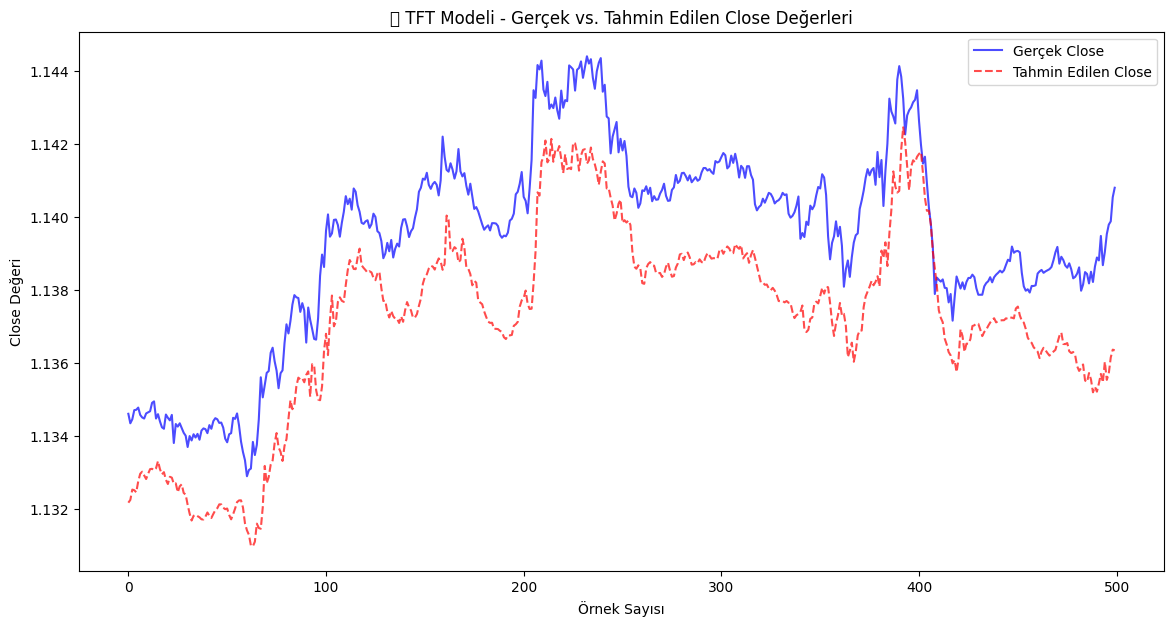

📊 R² Score: 0.9985939264297485
📉 Mean Squared Error (MSE): 0.000006
📌 Mean Absolute Error (MAE): 0.002200


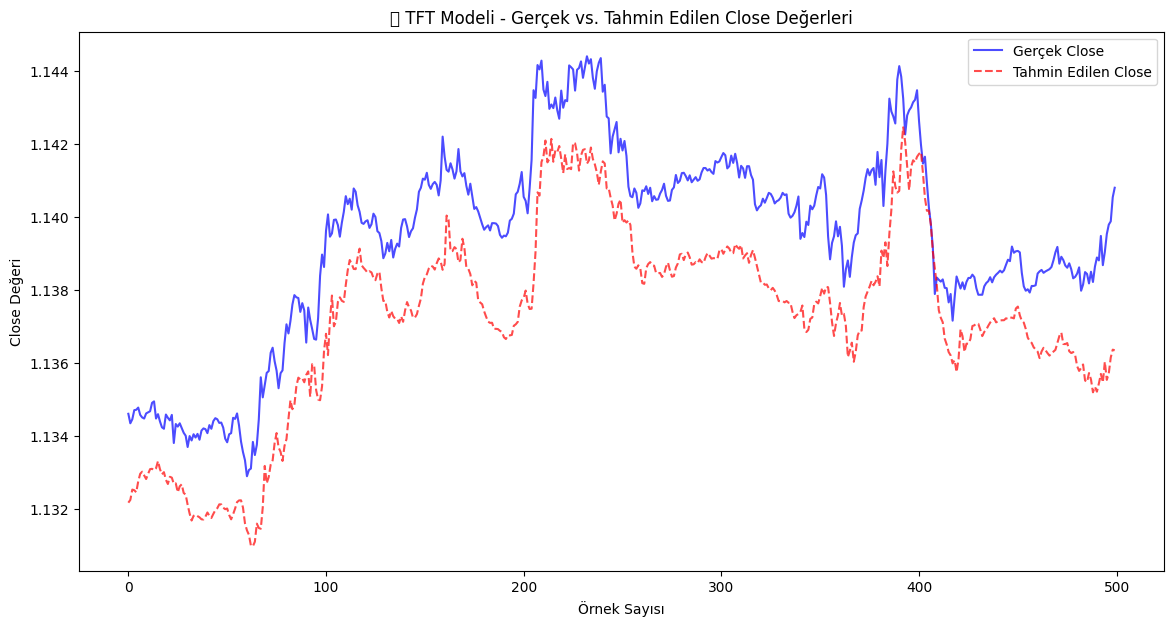

In [ ]:
# 📌 Modeli Test Seti Üzerinde Değerlendir
model.eval()
true_values = []
predicted_values = []

with torch.no_grad():
    for batch in test_loader:
        # 📌 Batch formatını kontrol et ve ayrıştır
        if isinstance(batch, (list, tuple)):
            if len(batch) == 3:
                past_x, future_x, batch_y = batch
            elif len(batch) == 2:
                x, batch_y = batch
                past_x, future_x = x, x  # Tek giriş varsa her ikisine de atayalım
            else:
                raise ValueError("Beklenmeyen batch formatı! (2 veya 3 öğe bekleniyor)")
        else:
            raise ValueError("Batch tipi beklenmedik formatta!")

        # Eğer ekstra boyut varsa kaldır (örneğin: [batch, 1, seq_len, num_vars] → [batch, seq_len, num_vars])
        if past_x.dim() == 4 and past_x.size(1) == 1:
            past_x = past_x.squeeze(1)
        if future_x.dim() == 4 and future_x.size(1) == 1:
            future_x = future_x.squeeze(1)

        # Verileri cihaza taşı
        past_x, future_x, batch_y = past_x.to(device), future_x.to(device), batch_y.to(device)

        # 📌 Model ile tahmin yap
        predictions = model(past_x, future_x).squeeze().cpu().numpy()
        true_values.extend(batch_y.cpu().numpy())
        predicted_values.extend(predictions)

# 📌 Tahminleri ve Gerçek Değerleri Karşılaştır
true_values = np.array(true_values)
predicted_values = np.array(predicted_values)

# 📌 R², MSE, MAE Skorlarını Hesapla
r2 = r2_score(true_values, predicted_values)
mse = mean_squared_error(true_values, predicted_values)
mae = mean_absolute_error(true_values, predicted_values)

# 📌 Sonuçları Yazdır
print(f"📊 R² Score: {r2:.4f}")
print(f"📉 Mean Squared Error (MSE): {mse:.6f}")
print(f"📌 Mean Absolute Error (MAE): {mae:.6f}")

# 📈 Tahmin Grafiği
plt.figure(figsize=(14, 7))
plt.plot(true_values[:500], label="Gerçek Close", linestyle="-", alpha=0.7, color='blue')
plt.plot(predicted_values[:500], label="Tahmin Edilen Close", linestyle="--", alpha=0.7, color='red')
plt.xlabel("Örnek Sayısı")
plt.ylabel("Close Değeri")
plt.title("📊 TFT Modeli - Gerçek vs. Tahmin Edilen Close Değerleri")
plt.legend()
plt.show()

# 📌 Sonuçları Yazdır
print(f"📊 R² Score: {r2}")
print(f"📉 Mean Squared Error (MSE): {mse:.6f}")
print(f"📌 Mean Absolute Error (MAE): {mae:.6f}")

# 📈 Tahmin Grafiği
plt.figure(figsize=(14, 7))
plt.plot(true_values[:500], label="Gerçek Close", linestyle="-", alpha=0.7, color='blue')
plt.plot(predicted_values[:500], label="Tahmin Edilen Close", linestyle="--", alpha=0.7, color='red')
plt.xlabel("Örnek Sayısı")
plt.ylabel("Close Değeri")
plt.title("📊 TFT Modeli - Gerçek vs. Tahmin Edilen Close Değerleri")
plt.legend()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# 📌 Sinyal Verisi Oluştur
df_test = pd.DataFrame({
    "True_Close": true_values,  # Gerçek kapanış fiyatları
    "Predicted_Close": predicted_values  # Model tahminleri
})


# 📈 Sinyal Doğruluğu Grafiği
plt.figure(figsize=(14, 7))
plt.plot(df_test['True_Close'][:500], label="Gerçek Close", linestyle="-", alpha=0.7, color='blue')
plt.plot(df_test['Predicted_Close'][:500], label="Tahmin Edilen Close", linestyle="--", alpha=0.7, color='red')
plt.scatter(df_test.index[:500], df_test['Predicted_Close'][:500], c=df_test['Signal'][:500], cmap='coolwarm', label="Sinyaller", marker='x')
plt.xlabel("Örnek Sayısı")
plt.ylabel("Close Değeri")
plt.title(f"📊 Sinyal Doğruluk Testi | Doğruluk: {accuracy:.4f}")
plt.legend()
plt.show()


ValueError: Found input variables with inconsistent numbers of samples: [124688, 124687]

In [ ]:
!pip install backtesting


In [ ]:
# 📌 Gerekli Kütüphaneleri Yükle
from backtesting import Backtest, Strategy
from backtesting.lib import crossover
from backtesting.test import SMA
import pandas as pd
import numpy as np

# 📌 Backtesting için Veri Çerçevesi (Zaman Serisi Formatı)
df_backtest = pd.DataFrame({
    "Close": df_test["True_Close"],  # Gerçek kapanış fiyatları
    "Open": df_test["True_Close"].shift(1),  # Açılış fiyatı (Önceki kapanış olarak kullanıyoruz)
    "High": df_test["True_Close"].rolling(3).max(),  # Son 3 periyotun maksimumu
    "Low": df_test["True_Close"].rolling(3).min(),  # Son 3 periyotun minimumu
    "Signal": df_test["Signal"]  # Modelin AL/SAT sinyalleri
}).dropna()

# 📌 Strateji Tanımlama
class AITradingStrategy(Strategy):
    def init(self):
        pass

    def next(self):
        if self.data.Signal[-1] == 1:  # Model AL sinyali veriyorsa
            self.buy()
        elif self.data.Signal[-1] == 0:  # Model SAT sinyali veriyorsa
            self.sell()

# 📌 Backtesti Çalıştır
bt = Backtest(df_backtest, AITradingStrategy, cash=10_000, commission=0.0002)
stats = bt.run()



# 📌 Performans Metriklerini Yazdır
print(stats)

/usr/local/lib/python3.11/dist-packages/backtesting/backtesting.py:1105: FutureWarning: Index.is_numeric is deprecated. Use pandas.api.types.is_any_real_numeric_dtype instead
  (data.index.is_numeric() and
<ipython-input-54-053292cc97e9>:29: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(df_backtest, AITradingStrategy, cash=10_000, commission=0.0002)


Start                                     2.0
End                                  124687.0
Duration                             124685.0
Exposure Time [%]                     99.9984
Equity Final [$]                  10526.89733
Equity Peak [$]                    10737.3059
Return [%]                            5.26897
Buy & Hold Return [%]                -2.61888
Return (Ann.) [%]                         0.0
Volatility (Ann.) [%]                     NaN
Sharpe Ratio                              NaN
Sortino Ratio                             NaN
Calmar Ratio                              0.0
Max. Drawdown [%]                    -14.6917
Avg. Drawdown [%]                     -0.5956
Max. Drawdown Duration                49982.0
Avg. Drawdown Duration             1354.27174
# Trades                                178.0
Win Rate [%]                            100.0
Best Trade [%]                        3.91926
Worst Trade [%]                       0.42953
Avg. Trade [%]                    

In [ ]:
import pandas as pd

# 📌 Test setini oluşturma - Timestamp eşitleme taktiği ile
start_idx = len(df) - len(y_test_lstm_inverse)
end_idx = len(df)

# Minimum uzunluğu belirleyelim
min_len = min(len(df.index[start_idx:end_idx]),
              len(y_test_lstm_inverse.flatten()),
              len(y_pred_lstm_inverse.flatten()),
              len(df['High'].iloc[start_idx:end_idx]),
              len(df['Low'].iloc[start_idx:end_idx]),
              len(df['Open'].iloc[start_idx:end_idx]))

# 📌 Test veri setini oluşturma (eşit uzunluklarda olacak şekilde)
df_test = pd.DataFrame({
    'Timestamp': df.index[start_idx:start_idx + min_len],
    'Close': y_test_lstm_inverse.flatten()[:min_len],
    'Predicted_Close': y_pred_lstm_inverse.flatten()[:min_len],
    'High': df['High'].iloc[start_idx:start_idx + min_len].values,
    'Low': df['Low'].iloc[start_idx:start_idx + min_len].values,
    'Open': df['Open'].iloc[start_idx:start_idx + min_len].values
})

# 📌 Timestamp'i indeks olarak ayarla (Backtest için gerekli)
df_test['Timestamp'] = pd.to_datetime(df_test['Timestamp'])
df_test.set_index('Timestamp', inplace=True)

# 📌 Sinyallerin hesaplanması
df_test['Signal'] = (df_test['Predicted_Close'] > df_test['Close']).astype(int)  # 1: Al, 0: Sat

# 📌 Gerçek sinyallerin hesaplanması
df_test['True_Signal'] = (df_test['Close'].shift(-1) > df_test['Close']).astype(int)  # 1: Yükseliş, 0: Düşüş

# 📌 Doğruluk oranını hesapla (Son satır atlanır çünkü geleceğe erişemeyiz)
accuracy = (df_test['Signal'][:-1] == df_test['True_Signal'][:-1]).mean()

# 📌 Sonuçları yazdır
print(f"📊 Doğru Sinyal Oranı: {accuracy:.4f}")

# 📈 Grafiği oluşturma
plt.figure(figsize=(14, 7))
plt.plot(df_test['Close'][:500], label="Gerçek Close", linestyle="-", alpha=0.7, color='blue')
plt.plot(df_test['Predicted_Close'][:500], label="Tahmin Edilen Close", linestyle="--", alpha=0.7, color='red')
plt.scatter(df_test.index[:500], df_test['Predicted_Close'][:500], c=df_test['Signal'][:500], cmap='coolwarm', label="Sinyaller", marker='x')
plt.xlabel("Zaman")
plt.ylabel("Close Değeri")
plt.title(f"📊 Sinyal Doğruluk Testi | Doğruluk: {accuracy:.4f}")
plt.legend()
plt.show()

# 📌 Oluşturulan test veri setini göster
import ace_tools as tools
tools.display_dataframe_to_user(name="df_test", dataframe=df_test)


NameError: name 'y_test_lstm_inverse' is not defined

In [ ]:
# 📌 Backtesting için Veri Çerçevesi (Zaman Serisi Formatı) - Timestamp Eklendi
df_backtest = pd.DataFrame({
    "Timestamp": df_test.index,  # Zaman damgası
    "Close": df_test["True_Close"],  # Gerçek kapanış fiyatları
    "Open": df_test["True_Close"].shift(1),  # Açılış fiyatı (Önceki kapanış olarak kullanıyoruz)
    "High": df_test["True_Close"].rolling(3).max(),  # Son 3 periyotun maksimumu
    "Low": df_test["True_Close"].rolling(3).min(),  # Son 3 periyotun minimumu
    "Signal": df_test["Signal"]  # Modelin AL/SAT sinyalleri
}).dropna()

# 📌 Zaman damgasını datetime formatına çevir
df_backtest["Timestamp"] = pd.to_datetime(df_backtest["Timestamp"])

# 📌 Timestamp'ı indeks olarak ayarla (Backtesting.py bunu gerektirir)
df_backtest.set_index("Timestamp", inplace=True)

# 📌 Strateji Tanımlama
class AITradingStrategy(Strategy):
    def init(self):
        pass

    def next(self):
        if self.data.Signal[-1] == 1:  # Model AL sinyali veriyorsa
            self.buy()
        elif self.data.Signal[-1] == 0:  # Model SAT sinyali veriyorsa
            self.sell()

# 📌 Backtesti Çalıştır
bt = Backtest(df_backtest, AITradingStrategy, cash=10_000, commission=0.0002)
stats = bt.run()

# 📌 Performans Metriklerini Yazdır
print(stats)




Start                     1970-01-01 00:00...
End                       1970-01-01 00:00...
Duration                  0 days 00:00:00....
Exposure Time [%]                     99.9984
Equity Final [$]                  10526.89733
Equity Peak [$]                    10737.3059
Return [%]                            5.26897
Buy & Hold Return [%]                -2.61888
Return (Ann.) [%]                         0.0
Volatility (Ann.) [%]                     NaN
CAGR [%]                                  NaN
Sharpe Ratio                              NaN
Sortino Ratio                             NaN
Calmar Ratio                              0.0
Max. Drawdown [%]                    -14.6917
Avg. Drawdown [%]                     -0.5956
Max. Drawdown Duration    0 days 00:00:00....
Avg. Drawdown Duration    0 days 00:00:00....
# Trades                                  178
Win Rate [%]                            100.0
Best Trade [%]                        3.91926
Worst Trade [%]                   

📊 Doğru Sinyal Oranı: 0.5092


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


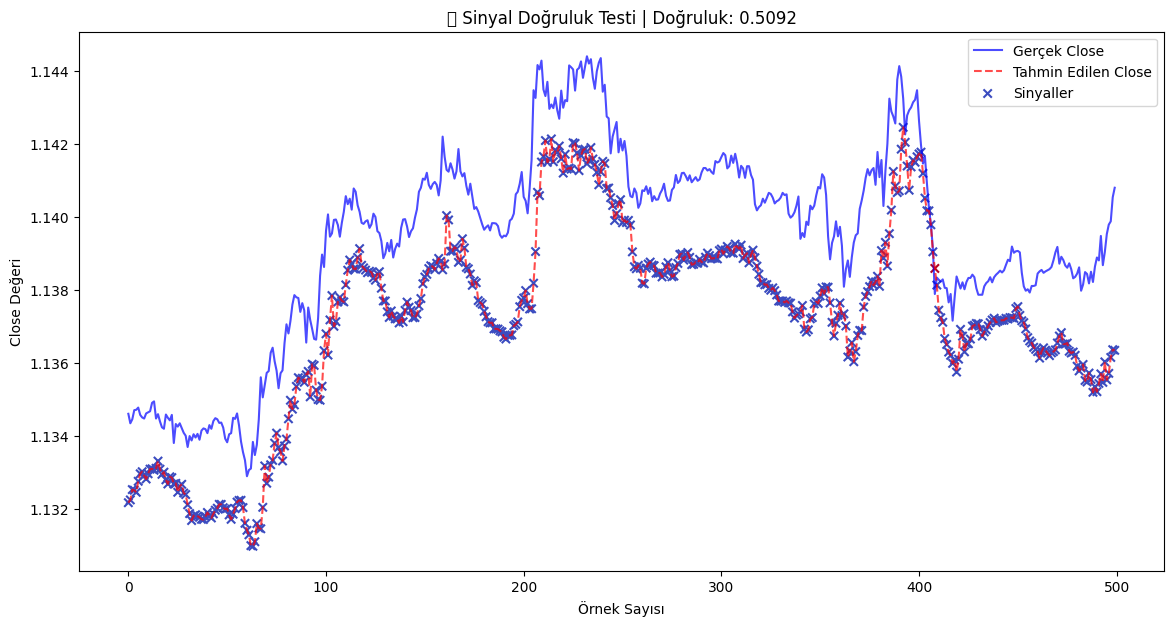

In [ ]:
# 📌 Doğru Sinyalleri Say ve Oranı Hesapla (Dizi Uzunluklarını Eşitleme)
accuracy = accuracy_score(df_test['True_Signal'].iloc[:-1], df_test['Signal'].iloc[:-1])  # Son satırı hariç tut

# 📌 Doğru Sinyal Oranı
print(f"📊 Doğru Sinyal Oranı: {accuracy:.4f}")

# 📈 Sinyal Doğruluğu Grafiği
plt.figure(figsize=(14, 7))
plt.plot(df_test['True_Close'][:500], label="Gerçek Close", linestyle="-", alpha=0.7, color='blue')
plt.plot(df_test['Predicted_Close'][:500], label="Tahmin Edilen Close", linestyle="--", alpha=0.7, color='red')
plt.scatter(df_test.index[:500], df_test['Predicted_Close'][:500], c=df_test['Signal'][:500], cmap='coolwarm', label="Sinyaller", marker='x')
plt.xlabel("Örnek Sayısı")
plt.ylabel("Close Değeri")
plt.title(f"📊 Sinyal Doğruluk Testi | Doğruluk: {accuracy:.4f}")
plt.legend()
plt.show()


In [ ]:
!pip install pybacktest

In [ ]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import time

# --------------------------------------------------------------------------------
# 1. MODEL PERFORMANS DEĞERLENDİRME FONKSİYONLARI
# --------------------------------------------------------------------------------

def evaluate_model(model, data_loader, device):
    """
    Test Loader’dan modeli çalıştırarak tüm tahminleri ve gerçek değerleri toplar.
    Modelin veri loader’ındaki (past, future, target) formatına göre esnek davranır.
    """
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for batch in data_loader:
            # Batch formatı 2 veya 3 öğe içerebilir.
            if isinstance(batch, (list, tuple)):
                if len(batch) == 2:
                    x, target = batch
                    past_x, future_x = x, x  # Tek girdiyi hem geçmiş hem gelecek olarak kullanıyoruz
                elif len(batch) == 3:
                    past_x, future_x, target = batch
                else:
                    raise ValueError("Beklenmeyen batch formatı.")
            else:
                raise ValueError("Batch tipi beklenmeyen formatta!")

            past_x = past_x.to(device)
            future_x = future_x.to(device)
            target = target.to(device)

            preds = model(past_x, future_x)
            all_preds.append(preds.squeeze().cpu().numpy())
            all_targets.append(target.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    return all_targets, all_preds


def compute_metrics(y_true, y_pred):
    """
    Gerçek ve tahmin değerlerine göre R², MSE ve MAE hesaplar.
    """
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    return r2, mse, mae


def plot_predictions(y_true, y_pred):
    """
    Zaman serisi çizimi ve dağılım (scatter) grafiği ile tahmin ve gerçek değerleri karşılaştırır.
    """
    plt.figure(figsize=(12,6))
    plt.plot(y_true, label='Gerçek Close')
    plt.plot(y_pred, label='Tahmin Edilen Close')
    plt.title("Gerçek vs Tahmin Edilen Close Fiyatları")
    plt.xlabel("Zaman")
    plt.ylabel("Close Fiyatı")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.xlabel("Gerçek")
    plt.ylabel("Tahmin")
    plt.title("Gerçek ve Tahmin Arasındaki İlişki")
    # 45° çizgisi
    min_val, max_val = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.show()


In [ ]:
!pip install backtesting


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.5/178.5 kB 6.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from backtesting import Backtest, Strategy
import time

# =============================================================================
# 1. MODEL PERFORMANS DEĞERLENDİRME FONKSİYONLARI
# =============================================================================

def evaluate_model(model, data_loader, device):
    """
    Test Loader üzerinden modelin tahminlerini ve gerçek değerlerini toplar.
    Batch formatı: (past, future, target) veya (x, target) şeklinde olabilir.
    """
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for batch in data_loader:
            # Batch 2 veya 3 öğeden oluşabilir.
            if isinstance(batch, (list, tuple)):
                if len(batch) == 3:
                    past_x, future_x, target = batch
                elif len(batch) == 2:
                    x, target = batch
                    past_x, future_x = x, x  # Tek girdi hem geçmiş hem gelecek olarak kullanılıyor
                else:
                    raise ValueError("Beklenmeyen batch formatı!")
            else:
                raise ValueError("Batch tipi beklenmeyen formatta!")

            past_x = past_x.to(device)
            future_x = future_x.to(device)
            target = target.to(device)

            preds = model(past_x, future_x)
            all_preds.append(preds.squeeze().cpu().numpy())
            all_targets.append(target.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    return all_targets, all_preds


def compute_metrics(y_true, y_pred):
    """
    Gerçek ve tahmin değerlerine göre R², MSE ve MAE hesaplar.
    """
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    return r2, mse, mae


def plot_predictions(y_true, y_pred):
    """
    Gerçek ve tahmin edilen Close fiyatlarının zaman serisi ve scatter grafiklerini çizer.
    """
    plt.figure(figsize=(12,6))
    plt.plot(y_true, label='Gerçek Close')
    plt.plot(y_pred, label='Tahmin Edilen Close')
    plt.title("Gerçek vs Tahmin Edilen Close Fiyatları")
    plt.xlabel("Zaman")
    plt.ylabel("Fiyat")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.xlabel("Gerçek")
    plt.ylabel("Tahmin")
    plt.title("Gerçek ve Tahmin Arasındaki İlişki")
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.show()


# =============================================================================
# 2. BACKTEST STRATEJİSİ (backtesting.py kullanılarak)
# =============================================================================

class TFTStrategy(Strategy):
    """
    Modelin ürettiği tahminlere (predicted_close) dayalı alım-satım stratejisi.
    - Eğer modelin tahmini artıyorsa long pozisyon (BUY),
    - Düşüyorsa short pozisyon (SELL) açılır.
    Stop-loss ve take-profit seviyeleri belirlenmiştir.
    """
    # Risk yönetimi parametreleri
    STOP_LOSS_PCT = 0.005    # %0.5 stop-loss
    TAKE_PROFIT_PCT = 0.01   # %1 take-profit

    def next(self):
        # Yeterli geçmiş yoksa işlem yapma
        if len(self.data) < 2:
            return

        # additional column 'predicted_close' DataFrame'e eklenmiş olmalı
        current_pred = self.data.predicted_close[-1]
        prev_pred = self.data.predicted_close[-2]
        price = self.data.Close[-1]

        # Bullish sinyal: Tahmin artış gösteriyorsa
        if current_pred > prev_pred:
            # Eğer kısa pozisyon varsa kapat
            if self.position and self.position.is_short:
                self.position.close()
            # Eğer pozisyon yoksa long pozisyon aç
            if not self.position:
                self.buy(sl=price * (1 - self.STOP_LOSS_PCT), tp=price * (1 + self.TAKE_PROFIT_PCT))

        # Bearish sinyal: Tahmin düşüş gösteriyorsa
        elif current_pred < prev_pred:
            # Eğer uzun pozisyon varsa kapat
            if self.position and self.position.is_long:
                self.position.close()
            # Eğer pozisyon yoksa short pozisyon aç
            if not self.position:
                self.sell(sl=price * (1 + self.STOP_LOSS_PCT), tp=price * (1 - self.TAKE_PROFIT_PCT))


# =============================================================================
# 3. MODEL DEĞERLENDİRME VE BACKTEST İŞLEMLERİNİN BİRLEŞTİRDİĞİ ANA FONKSİYON
# =============================================================================

def main_evaluation_and_backtest(model, test_loader, df_test, device, sequence_length=60):
    """
    1. Test Loader kullanılarak modelin performansı değerlendirilir.
    2. Elde edilen tahminler, OHLC verilerini içeren df_test'e hizalanır.
    3. backtesting.py kütüphanesiyle strateji testi gerçekleştirilir.
    """
    # A. Model Performans Değerlendirmesi
    y_true, y_pred = evaluate_model(model, test_loader, device)
    r2, mse, mae = compute_metrics(y_true, y_pred)
    print("=== Model Performans Değerleri ===")
    print(f"R²: {r2:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")

    plot_predictions(y_true, y_pred)

    # B. df_test ile tahminlerin hizalanması
    # Sequence_length nedeniyle, test_loader'dan gelen y_pred, df_test'in ilk satırlarından kayabilir.
    if len(df_test) > len(y_pred):
        df_test_aligned = df_test.iloc[sequence_length:sequence_length + len(y_pred)].copy()
    else:
        df_test_aligned = df_test.copy().iloc[-len(y_pred):]

    # Tahminleri "predicted_close" sütunu olarak ekleyelim.
    df_test_aligned['predicted_close'] = y_pred

    # Backtesting.py'nin doğru çalışması için df_test'in en az "Open", "High", "Low", "Close" sütunlarını içermesi gerekir.
    # Eğer eksikse, örneğin "Open", "High", "Low" sütunlarını "Close" değerleriyle dolduralım.
    for col in ['Open', 'High', 'Low', 'Close']:
        if col not in df_test_aligned.columns:
            df_test_aligned[col] = df_test_aligned['Close']

    # C. Backtest Uygulaması
    bt = Backtest(df_test_aligned, TFTStrategy, cash=100000, commission=0.000, trade_on_close=True)
    stats = bt.run()
    print("=== Backtest Sonuçları ===")
    print(stats)
    bt.plot()

    return y_true, y_pred, stats




/usr/local/lib/python3.11/dist-packages/backtesting/_plotting.py:50: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support (e.g. PyCharm, Spyder IDE). Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


In [ ]:
import torch
import gc

torch.cuda.empty_cache()  # GPU önbelleğini temizle
gc.collect()  # Kullanılmayan nesneleri temizle


1383

In [ ]:
import os
import gc  # Garbage collection module
import torch

# 1. Free up PyTorch memory
torch.cuda.empty_cache()

# 2. Run garbage collection to release unused memory
gc.collect()

# 3. Reset CUDA if available
if torch.cuda.is_available():
    os.environ['CUDA_LAUNCH_BLOCKING'] = '1'  # Enable synchronous error reporting
    torch.cuda.synchronize()  # Synchronize with GPU operations

    # Reset device and contexts
    torch.cuda.set_device(torch.cuda.current_device())
    torch.cuda.init()

    # Check if reset was successful (may not be possible in all environments)
    try:
        torch.cuda.reset_peak_memory_stats()
        print("✅ GPU successfully reset!")
    except RuntimeError as e:
        print(f"⚠️ GPU reset failed: {e}")

# 4. Re-enable CuDNN if it was previously disabled
torch.backends.cudnn.enabled = True

✅ GPU successfully reset!


In [ ]:
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

class TemporalFusionTransformer(nn.Module):
    """
    Temporal Fusion Transformer architecture (Static features removed)
    """
    def __init__(self, temporal_dim, num_temporal_vars,
                 hidden_dim=64, output_dim=1, num_heads=4, dropout=0.1):
        super().__init__()
        self.hidden_dim = hidden_dim

        # Temporal variable selection
        self.temporal_vsn = VariableSelectionNetwork(
            num_vars=num_temporal_vars,
            hidden_dim=hidden_dim,
            dropout=dropout
        )

        # Temporal processing
        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=False
        )

        # Attention mechanisms
        self.temporal_attention = TemporalSelfAttention(hidden_dim, n_heads=num_heads, dropout=dropout)
        self.dynamic_attention = DynamicAttentionHeads(hidden_dim, n_heads=num_heads, dropout=dropout)

        # Positional encoding
        self.pos_encoder = PositionalEncoding(hidden_dim, dropout)

        # Output processing
        self.output_grn = GatedResidualNetwork(
            input_dim=hidden_dim*2,
            hidden_dim=hidden_dim,
            output_dim=output_dim,
            dropout=dropout
        )

        # Final output layer with uncertainty estimation
        self.noisy_output = NoisyLinear(output_dim, output_dim)

        # Initialization
        self._init_weights()

    def _init_weights(self):
        for name, p in self.named_parameters():
            if p.dim() < 2:  # Eğer tensör tek boyutluysa (bias gibi)
                nn.init.zeros_(p)  # Biasları sıfırla
            else:  # Ağırlık tensörleri için uygun başlatma fonksiyonları
                if 'lstm' in name:
                    nn.init.orthogonal_(p)  # LSTM için en uygun init yöntemi
                elif 'attention' in name or 'query' in name or 'key' in name or 'value' in name:
                    nn.init.xavier_uniform_(p)  # Attention katmanları için Xavier kullan
                else:
                    nn.init.xavier_uniform_(p)  # GELU yerine Xavier kullandık

    def forward(self, temporal_x):
        # Temporal variable selection
        temporal_selected = self.temporal_vsn(temporal_x)  # [B, T, H]

        # Add positional information
        temporal_selected = self.pos_encoder(temporal_selected)  # [B, T, H]

        # LSTM temporal processing
        lstm_out, _ = self.lstm(temporal_selected)  # [B, T, H]

        # Multi-head attention processing
        attn_out = self.temporal_attention(lstm_out)  # [B, T, H]
        dyn_attn_out = self.dynamic_attention(attn_out)  # [B, T, H]

        # Combine LSTM and attention outputs
        combined = torch.cat([lstm_out, dyn_attn_out], dim=-1)  # [B, T, 2H]

        # Final output processing
        output = self.output_grn(combined)  # [B, T, O]
        output = self.noisy_output(output)  # [B, T, O]

        return output[:, -1, :]  # Return last timestep prediction


# 📌 Dataset (Static Features Removed)
class MemmapDataset(torch.utils.data.Dataset):
    def __init__(self, memmap_array, target_array, sequence_length=60):
        self.memmap_array = memmap_array
        self.target_array = target_array
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.memmap_array) - self.sequence_length

    def __getitem__(self, idx):
        temporal = self.memmap_array[idx:idx + self.sequence_length]  # Zaman serisi verileri
        target = self.target_array[idx + self.sequence_length]  # Hedef değer

        return torch.tensor(temporal, dtype=torch.float32), \
               torch.tensor(target, dtype=torch.float32)


def train_model():
    # Device configuration
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Model parameters
    config = {
        'temporal_dim': 8,        # Update with per-temporal-variable feature dim
        'num_temporal_vars': 5,   # Update with number of temporal variables
        'hidden_dim': 64,
        'output_dim': 1,
        'num_heads': 4,
        'dropout': 0.1
    }

    # Initialize model
    model = TemporalFusionTransformer(**config).to(device)

    # Optimizer and scheduler
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=1e-3,
        weight_decay=1e-4
    )
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=3
    )

    # Loss function
    loss_fn = nn.HuberLoss(delta=1.0)

    # Training loop
    num_epochs = 10
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for batch_idx, (temporal, targets) in enumerate(train_loader):
            temporal = temporal.to(device).float()
            targets = targets.to(device).float()

            optimizer.zero_grad()
            outputs = model(temporal)
            loss = loss_fn(outputs, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item() * temporal.size(0)

        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for temporal, targets in val_loader:
                temporal = temporal.to(device).float()
                targets = targets.to(device).float()

                outputs = model(temporal)
                loss = loss_fn(outputs, targets)
                val_loss += loss.item() * temporal.size(0)

        train_loss /= len(train_dataset)
        val_loss /= len(val_dataset)
        scheduler.step(val_loss)

        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # Test phase
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for temporal, targets in test_loader:
            temporal = temporal.to(device).float()
            targets = targets.to(device).float()

            outputs = model(temporal)
            test_loss += loss_fn(outputs, targets).item() * temporal.size(0)

    test_loss /= len(test_dataset)
    print(f"\nFinal Test Loss: {test_loss:.4f}")


# 📌 Data Loaders
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# Start training
if __name__ == "__main__":
    train_model()


Using device: cuda


RuntimeError: input.size(-1) must be equal to input_size. Expected 64, got 28

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class PositionalEncoding(nn.Module):
    """
    Sinüs-kosinus tabanlı konum kodlaması (positional encoding).
    Zaman serisi verisinde (veya NLP'de) konum bilgisini modele dahil etmek için kullanılır.

    Args:
        d_model (int): Giriş/çıktı vektörünün boyutu (örneğin hidden_dim).
        dropout (float, optional): Konum kodlaması sonrasında uygulanacak dropout oranı.
                                   Varsayılan 0.1.
        max_len (int, optional): Maksimum zaman adımı (sequence length). Varsayılan 5000.
    """
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Konum indeksleri (0, 1, 2, ..., max_len-1)
        position = torch.arange(max_len).unsqueeze(1)
        # d_model boyutunda frekans bileşenleri
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))

        # Sin ve cos değerlerini saklayacağımız tensör
        pe = torch.zeros(1, max_len, d_model)
        pe[0, :, 0::2] = torch.sin(position * div_term)  # çift indekslere sin
        pe[0, :, 1::2] = torch.cos(position * div_term)  # tek indekslere cos

        # Bu tensör modelin öğrenebilir parametresi değildir, ancak .pth kaydında saklanır.
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x (torch.Tensor): Şekil (batch_size, seq_len, d_model) olan tensör.

        Returns:
            torch.Tensor: Aynı şekilde (batch_size, seq_len, d_model) boyutlu,
                          konum bilgisi eklenmiş tensör.
        """
        seq_len = x.size(1)
        # Konum bilgisini ekliyoruz
        x = x + self.pe[:, :seq_len]
        return self.dropout(x)


class TemporalSelfAttention(nn.Module):
    """
    Basit bir Temporal Self-Attention katmanı.
    - Sinusoidal konum kodlaması
    - Multi-head mekanizması (isteğe bağlı olarak n_heads=1, 2, vs. kullanılabilir)
    - Scaled Dot-Product Attention
    - Residual ve Layer Norm

    Args:
        hidden_dim (int): Giriş ve çıkışın boyutu.
        n_heads (int, optional): Attention başlık sayısı. Varsayılan 1.
        dropout (float, optional): Dropout oranı. Varsayılan 0.1.
    """
    def __init__(self, hidden_dim: int, n_heads: int = 1, dropout: float = 0.1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_heads = n_heads

        # Sorgu, Anahtar, Değer dönüşümleri
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)

        # Konum kodlaması (sinusoidal)
        self.pos_encoder = PositionalEncoding(d_model=hidden_dim, dropout=dropout)

        # Attention sonrası dropout
        self.attn_dropout = nn.Dropout(dropout)

        # Katman norm
        self.layer_norm = nn.LayerNorm(hidden_dim)

        # Basit bir FFN (feed-forward network)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.GELU(),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x: torch.Tensor, mask: torch.Tensor = None) -> torch.Tensor:
        """
        Args:
            x (torch.Tensor): (batch_size, seq_len, hidden_dim) giriş tensörü.
            mask (torch.Tensor, optional): Attention maskesi. İstenirse eklenebilir.

        Returns:
            torch.Tensor: (batch_size, seq_len, hidden_dim) çıktı tensörü.
        """
        residual = x
        # Konum kodlaması eklenerek layer normalization uygulanır
        x = self.layer_norm(x + self.pos_encoder(x))

        # Q-K-V
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        # PyTorch 2.0+'da gelen F._scaled_dot_product_attention fonksiyonu kullanılıyor
        attn_output, _ = F._scaled_dot_product_attention(
            q, k, v,
            attn_mask=mask,
            dropout_p=self.attn_dropout.p if self.training else 0
        )

        # Feed-forward
        output = self.fc(attn_output)
        # Residual connection + layer norm
        return self.layer_norm(output + residual)


class DynamicAttentionHeads(nn.Module):
    """
    Birden fazla TemporalSelfAttention katmanını paralel çalıştırır ve
    her bir başlığın çıktısını öğrenilebilir gating mekanizmasıyla birleştirir.

    Args:
        hidden_dim (int): Attention katmanlarının giriş/çıkış boyutu.
        n_heads (int): Kaç farklı attention head'i paralel çalıştırılacak.
        dropout (float, optional): Dropout oranı. Varsayılan 0.1.
    """
    def __init__(self, hidden_dim: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        # Her head = 1'er adet TemporalSelfAttention -> n_heads tane
        self.heads = nn.ModuleList([
            TemporalSelfAttention(hidden_dim, n_heads=1, dropout=dropout)
            for _ in range(n_heads)
        ])

        # Head'lerin çıktılarını birleştirmek için öğrenilebilir gating mekanizması
        self.gate = nn.Sequential(
            nn.Linear(hidden_dim * n_heads, n_heads),
            nn.Softmax(dim=-1)
        )

        # Son işlem: layer norm, residual bağlantı
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.residual = nn.Linear(hidden_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x (torch.Tensor): (batch_size, seq_len, hidden_dim) giriş tensörü

        Returns:
            torch.Tensor: (batch_size, seq_len, hidden_dim) çıktı tensörü
        """
        residual = self.residual(x)

        # Her bir attention head'in çıktısı
        head_outputs = [head(x) for head in self.heads]  # list of (B, T, D)
        # Hepsini son boyuta göre stack'liyoruz -> (B, T, D, n_heads)
        stacked = torch.stack(head_outputs, dim=-1)

        # Gating ağı için shape (B, T, D*n_heads) yapıyoruz
        gate_weights = self.gate(stacked.flatten(start_dim=-2))  # (B, T, n_heads)

        # Her head'i gate ağırlıklarıyla çarpıp topluyoruz
        combined = (stacked * gate_weights.unsqueeze(-2)).sum(dim=-1)  # (B, T, D)

        # Residual + layer norm
        return self.layer_norm(combined + residual)


class VariableSelectionNetwork(nn.Module):
    """
    Feature-wise soft selection mekanizması.
    Zaman serisi feature'larını dinamik olarak önem ağırlıklarına göre birleştirir.

    Args:
        num_vars (int): Kaç farklı feature (değişken) olduğu.
        hidden_dim (int): Her bir feature'ın dönüştürüleceği boyut.
        dropout (float, optional): Dropout oranı. Varsayılan 0.1.
    """
    def __init__(self, num_vars: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        self.num_vars = num_vars
        self.hidden_dim = hidden_dim

        # GRU tabanlı context üretici
        self.context_gen = nn.GRU(input_size=hidden_dim, hidden_size=hidden_dim, batch_first=True)

        # Feature selection weight ağı
        self.weight_net = nn.Sequential(
            nn.Linear(hidden_dim * 2, num_vars),
            nn.Softmax(dim=-1)
        )

        # Her feature için ayrı bir dönüşüm
        self.feature_transforms = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(num_vars)
        ])

        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim)

    def forward(self, x: torch.Tensor, static_context: torch.Tensor = None) -> torch.Tensor:
        """
        Args:
            x (torch.Tensor): Şekil (B, T, num_vars, hidden_dim).
            static_context (torch.Tensor, optional): Statik (batch_size, hidden_dim) boyutunda
                                                     ek bilgi. İstenirse katılabilir.

        Returns:
            torch.Tensor: (B, T, hidden_dim) boyutunda, seçilmiş/özetlenmiş feature temsili.
        """
        batch_size, seq_len, num_vars, _ = x.shape

        # Dinamik kontekst (context) üretimi
        if static_context is not None:
            # Statik bilgiyi her zaman adımına kopyala
            context = static_context.unsqueeze(1).expand(-1, seq_len, -1)
        else:
            # GRU'ya, x içerisindeki feature'ların ortalamasını veriyoruz
            gru_input = x.mean(dim=2)  # (B, T, hidden_dim)
            context, _ = self.context_gen(gru_input)  # (B, T, hidden_dim)

        # Feature seçim ağırlıkları
        # x.mean(dim=2) -> (B, T, hidden_dim)
        # cat([x.mean, context], dim=-1) -> (B, T, 2*hidden_dim)
        weights = self.weight_net(torch.cat([x.mean(dim=2), context], dim=-1))
        weights = self.dropout(weights)  # (B, T, num_vars)

        # Her feature'ı dönüştür
        transformed = torch.stack([
            self.feature_transforms[i](x[..., i, :]) for i in range(num_vars)
        ], dim=-2)  # (B, T, num_vars, hidden_dim)

        # Ağırlıklı toplama: (B, T, hidden_dim)
        weighted = transformed * weights.unsqueeze(-1)
        selected = weighted.sum(dim=-2)

        # Layer normalization
        return self.layer_norm(selected)


class GatedResidualNetwork(nn.Module):
    """
    Gated Residual Network (GRN):
      - GLU (Gated Linear Unit) tabanlı gating
      - Residual bağlantı
      - Layer norm

    Args:
        input_dim (int): Giriş boyutu.
        hidden_dim (int): Ara katmanda kullanılacak boyut.
        output_dim (int, optional): Çıkış boyutu. Belirtilmezse input_dim ile aynı alınır.
        dropout (float, optional): Dropout oranı. Varsayılan 0.1.
    """
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int = None, dropout: float = 0.1):
        super().__init__()
        if output_dim is None:
            output_dim = input_dim

        # GLU Gating
        self.gate = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GLU(dim=-1),
            nn.Dropout(dropout)
        )

        # Ana dönüşümler (dense katmanlar)
        self.dense = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.Dropout(dropout)
        )

        # Residual bağlantı
        self.residual = nn.Linear(input_dim, output_dim) if input_dim != output_dim else nn.Identity()
        self.layer_norm = nn.LayerNorm(output_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x (torch.Tensor): (B, T, input_dim) veya (B, input_dim) (uygulanacağı yere göre)

        Returns:
            torch.Tensor: Gated residual sonucu (B, T, output_dim) veya (B, output_dim)
        """
        # GLU ile gating
        gate = self.gate(x)
        # Dense katman
        transformed = self.dense(x)
        # Gated + residual
        output = self.layer_norm(transformed * gate + self.residual(x))
        return output


class NoisyLinear(nn.Module):
    """
    Noisy Linear katmanı (NoisyNet):
      - Ağırlıklara ve bias'a faktörize Gaussian gürültü ekleyerek,
        öğrenme aşamasında belirsizlik ve exploration imkanı sunar.
      - Özellikle RL çalışmalarında popülerdir, ancak TFT gibi modellere de
        ek bir düzenleme (regularization) olarak dahil edilebilir.

    Args:
        in_features (int): Girdi boyutu.
        out_features (int): Çıkış boyutu.
        sigma_init (float, optional): Gürültü standard sapması için başlangıç değeri. Varsayılan 0.017.
    """
    def __init__(self, in_features: int, out_features: int, sigma_init: float = 0.017):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.sigma_init = sigma_init

        # Öğrenilebilir parametreler
        self.weight_mu = nn.Parameter(torch.Tensor(out_features, in_features))
        self.weight_sigma = nn.Parameter(torch.Tensor(out_features, in_features))
        self.register_buffer('weight_epsilon', torch.Tensor(out_features, in_features))

        self.bias_mu = nn.Parameter(torch.Tensor(out_features))
        self.bias_sigma = nn.Parameter(torch.Tensor(out_features))
        self.register_buffer('bias_epsilon', torch.Tensor(out_features))

        self.reset_parameters()
        self.reset_noise()

    def reset_parameters(self):
        # Ağırlıkların başlangıç aralığı
        mu_range = 1 / math.sqrt(self.in_features)
        self.weight_mu.data.uniform_(-mu_range, mu_range)
        self.weight_sigma.data.fill_(self.sigma_init)
        self.bias_mu.data.uniform_(-mu_range, mu_range)
        self.bias_sigma.data.fill_(self.sigma_init)

    def _scale_noise(self, size: int) -> torch.Tensor:
        """
        Factorized gürültü üretmek için kullanılan yardımcı fonksiyon.
        """
        x = torch.randn(size)
        return x.sign().mul_(x.abs().sqrt_())

    def reset_noise(self):
        """
        Her eğitim iterasyonunda yeniden çağrılarak gürültü tensörlerini
        (weight_epsilon, bias_epsilon) yeniden numaralandırır.
        """
        epsilon_in = self._scale_noise(self.in_features)
        epsilon_out = self._scale_noise(self.out_features)

        # outer product -> (out_features, in_features)
        self.weight_epsilon.copy_(epsilon_out.ger(epsilon_in))
        self.bias_epsilon.copy_(epsilon_out)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x (torch.Tensor): (batch_size, in_features)

        Returns:
            torch.Tensor: (batch_size, out_features)
        """
        if self.training:
            weight = self.weight_mu + self.weight_sigma * self.weight_epsilon
            bias = self.bias_mu + self.bias_sigma * self.bias_epsilon
        else:
            # Test aşamasında gürültü katmıyoruz
            weight = self.weight_mu
            bias = self.bias_mu

        return F.linear(x, weight, bias)


In [ ]:
# 📌 Modeli oluştur
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TemporalFusionTransformer(
    input_dim=len(selected_features),
    hidden_dim=128,
    num_heads=8,
    num_vars=len(selected_features),
    dropout=0.2
).to(device)

# 📌 Kayıp fonksiyonu ve optimizer
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 📌 Learning Rate Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class VariableSelectionNetwork(nn.Module):
    """
    Gerçek dünyada:
      - Embedding'lerin boyutu (embedding_dim)
      - Gating mekanizmasının tasarımı
      - Zaman boyutu (seq_len) üzerinden farklı stratejiler
    gibi faktörler devreye girer.

    Burada:
      - Her input_dim değişkeni için bir embedding (embedding_dim)
      - Zaman ve batch bazında gating (softmax) ile ağırlıklandırma
      - Sonuç: (batch, seq_len, embedding_dim) boyutunda birleştirilmiş temsil.
    """

    def __init__(self, input_dim, embedding_dim=32):
        super().__init__()
        self.input_dim = input_dim
        self.embedding_dim = embedding_dim

        # Her bir değişken (feature) için ayrı bir embedding vektörü
        # Boyut: (input_dim, embedding_dim)
        self.variable_embeddings = nn.Parameter(
            torch.randn(input_dim, embedding_dim) * 0.01
        )

        # Gating ağı: Zaman ve batch boyutu için
        # (batch, seq_len, input_dim) -> softmax -> ağırlıklar
        # Bu örnekte 2 katmanlı basit bir ağ + softmax var.
        self.gate_network = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.ReLU(),
            nn.Linear(input_dim, input_dim),
            nn.Softmax(dim=-1)   # Değişken ekseni üzerinde normalize
        )

    def forward(self, x):
        """
        x şekli: (batch_size, seq_len, input_dim)

        Adımlar:
          1) Gating ağı ile her time step ve her feature için bir ağırlık elde et (alpha).
          2) variable_embeddings'i (input_dim, embedding_dim) boyutundan
             (batch, seq_len, input_dim, embedding_dim) boyutuna "broadcast" ile çıkar.
          3) alpha ile embedding'leri çarpıp topla.

        Çıktı: (batch_size, seq_len, embedding_dim)
        """
        b, t, d = x.size()
        # Gating:
        #   x'i (b*t, d) => gate => (b*t, d) => reshape => (b, t, d)
        gating_input = x.reshape(b * t, d)
        alpha = self.gate_network(gating_input)
        alpha = alpha.view(b, t, d)  # (batch, seq_len, input_dim)

        # Embedding parametresi: (input_dim, embedding_dim)
        # Bunu (b, t, d, emb_dim) şeklinde genişletelim (broadcast)
        emb = self.variable_embeddings.unsqueeze(0).unsqueeze(0)  # (1,1,d,emb_dim)
        emb = emb.repeat(b, t, 1, 1)  # (b, t, d, emb_dim)

        # alpha'yı (b, t, d, 1) haline getirip element-wise çarpalım
        alpha = alpha.unsqueeze(-1)  # (b, t, d, 1)

        out = emb * alpha  # (b, t, d, emb_dim)
        # Değişken eksenini (d) toplayarak (batch, seq_len, embedding_dim) çıkarıyoruz
        out = out.sum(dim=2)  # (b, t, emb_dim)

        return out
class GatedResidualNetwork(nn.Module):
    """
    Resmi TFT makalesinde:
      - (GLU) Gated Linear Units
      - Norm katmanları
      - Opsiyonel dropout
    yer alır.
    Burada basit bir ELU + gating + skip bağlantısı gösterilmektedir.
    """
    def __init__(self, input_dim, hidden_dim, output_dim=None, dropout=0.0):
        super().__init__()
        if output_dim is None:
            output_dim = hidden_dim

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.elu = nn.ELU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

        # Gating
        self.gate = nn.Linear(output_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

        # Skip bağlantısı için
        # input_dim != output_dim ise boyut eşitlemesi
        self.skip = nn.Linear(input_dim, output_dim) if input_dim != output_dim else None

        # Layer norm (isteğe bağlı eklenebilir)
        self.layer_norm = nn.LayerNorm(output_dim)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        residual = x

        # 1) İleri besleme bloğu
        x = self.fc1(x)
        x = self.elu(x)
        x = self.fc2(x)
        x = self.dropout(x)

        # 2) Gating mekanizması
        gating = self.sigmoid(self.gate(x))

        # 3) Skip connection
        if self.skip is not None:
            residual = self.skip(residual)

        # 4) Gated ekleme
        x = (1 - gating) * residual + gating * x

        # 5) Opsiyonel Layer Norm
        x = self.layer_norm(x)

        return x
class TemporalSelfAttention(nn.Module):
    """
    Çok kafalı (multihead) self-attention katmanı.
    - batch_first=True sayesinde giriş (batch, seq_len, hidden_dim) formatında
    - gating ve skip connection ile zenginleştiriyoruz.
    """
    def __init__(self, hidden_dim, n_heads, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=hidden_dim,
                                          num_heads=n_heads,
                                          dropout=dropout,
                                          batch_first=True)

        self.gate = nn.Linear(hidden_dim, hidden_dim)
        self.sigmoid = nn.Sigmoid()
        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        x: (batch_size, seq_len, hidden_dim)
        """
        attn_output, _ = self.attn(x, x, x)  # Self-attention

        # Gating + skip connection
        gating = self.sigmoid(self.gate(attn_output))
        # (1 - gate) * eski + gate * yeni
        x_out = (1 - gating) * x + gating * attn_output

        x_out = self.norm(x_out)
        x_out = self.dropout(x_out)

        return x_out
class DynamicAttentionHeads(nn.Module):
    """
    Tek zaman adımında (batch, hidden_dim) veya (batch, hidden_dim*2) gibi
    2B veriler üzerinde attention/gating benzeri bir işlem yapabilir.
    """
    def __init__(self, input_dim, n_heads=4, dropout=0.1):
        super().__init__()
        self.attn_projection = nn.Linear(input_dim, input_dim)
        self.gate = nn.Linear(input_dim, input_dim)
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(input_dim)

    def forward(self, x):
        """
        x: (batch_size, input_dim)
        """
        proj = F.relu(self.attn_projection(x))   # Projeksiyon
        gating = self.sigmoid(self.gate(proj))   # Gating

        # Skip connection
        x_out = (1 - gating) * x + gating * proj

        x_out = self.dropout(x_out)
        x_out = self.norm(x_out)

        return x_out
class NoisyLinear(nn.Module):
    """
    NoisyNet: her katmanın ağırlık ve bias'larına öğrenilebilir bir gürültü eklenir.
    Özellikle RL'de (DQN gibi) keşif/exploration amaçlı sık kullanılır.

    Referans:
      "Noisy Networks for Exploration" (Fortunato et al.)
    """
    def __init__(self, in_features, out_features, sigma_init=0.017):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        # Temel (mu) parametreleri
        self.weight_mu = nn.Parameter(torch.empty(out_features, in_features))
        self.bias_mu   = nn.Parameter(torch.empty(out_features))

        # Gürültü (sigma) parametreleri
        self.weight_sigma = nn.Parameter(torch.empty(out_features, in_features))
        self.bias_sigma   = nn.Parameter(torch.empty(out_features))

        # Epsilon değerleri (her forward'da resetlenir)
        self.register_buffer("weight_epsilon", torch.empty(out_features, in_features))
        self.register_buffer("bias_epsilon", torch.empty(out_features))

        self.sigma_init = sigma_init
        self.reset_parameters()
        self.reset_noise()

    def reset_parameters(self):
        # Parametreleri küçük bir aralıkta başlatma
        mu_range = 1.0 / np.sqrt(self.in_features)

        self.weight_mu.data.uniform_(-mu_range, mu_range)
        self.bias_mu.data.uniform_(-mu_range, mu_range)

        self.weight_sigma.data.fill_(self.sigma_init)
        self.bias_sigma.data.fill_(self.sigma_init)

    def reset_noise(self):
        """
        Her forward öncesi çağrılabilir.
        Epsilon değerlerini yeniden örnekleyerek
        gürültüyü dinamik hale getirir.
        """
        epsilon_in  = torch.randn(self.in_features)
        epsilon_out = torch.randn(self.out_features)

        # Outer product -> (out_features, in_features)
        self.weight_epsilon = epsilon_out.ger(epsilon_in)
        self.bias_epsilon   = epsilon_out

    def forward(self, x):
        # Eğitim modunda gürültüyü ekle
        if self.training:
            weight = self.weight_mu + self.weight_sigma * self.weight_epsilon
            bias   = self.bias_mu   + self.bias_sigma   * self.bias_epsilon
        else:
            # Eval modunda ortalama değer (gürültüsüz)
            weight = self.weight_mu
            bias   = self.bias_mu




In [ ]:
import torch

# 📌 GPU varsa CUDA kullan, yoksa CPU'ya geç
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Kullanılan Cihaz: {device}")


🚀 Kullanılan Cihaz: cuda


In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def test_model(model, test_loader, device):
    model.to(device)
    model.eval()  # Modeli değerlendirme moduna al
    actual_prices, predicted_prices = [], []

    with torch.no_grad():  # Gradyan hesaplamasını kapat
        for batch_x, batch_y, _ in test_loader:  # Volatilite etiketi kullanılmıyor
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            # Modelden tahmin al
            price_pred, _ = model(batch_x)  # Volatility tahminini kullanmıyoruz
            price_pred = price_pred.squeeze().cpu().numpy()
            batch_y = batch_y.cpu().numpy()

            actual_prices.extend(batch_y)
            predicted_prices.extend(price_pred)

    # 📌 Performans Metriklerini Hesapla
    mse = mean_squared_error(actual_prices, predicted_prices)
    mae = mean_absolute_error(actual_prices, predicted_prices)
    r2 = r2_score(actual_prices, predicted_prices)

    print(f"\n📊 Test Sonuçları:")
    print(f"✅ Mean Squared Error (MSE): {mse:.5f}")
    print(f"✅ Mean Absolute Error (MAE): {mae:.5f}")
    print(f"✅ R² Skoru: {r2:.5f}")

    # 📌 Tahminleri Görselleştir
    plt.figure(figsize=(12, 5))
    plt.plot(actual_prices, label="Gerçek Fiyatlar", linestyle="dashed", alpha=0.7)
    plt.plot(predicted_prices, label="Tahmin Edilen Fiyatlar", alpha=0.7)
    plt.title("📈 Model Tahmin vs. Gerçek Fiyatlar")
    plt.xlabel("Zaman")
    plt.ylabel("Fiyat")
    plt.legend()
    plt.grid()
    plt.show()

    return mse, mae, r2


In [ ]:
def plot_loss_curve(train_losses, val_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss", marker='o', linestyle='--')
    plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss", marker='s', linestyle='-')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("📉 Eğitim ve Validasyon Loss Grafiği")
    plt.legend()
    plt.grid()
    plt.show()


In [ ]:
# 📌 PyTorch Forecasting'i yükle
!pip install pytorch-forecasting -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.9/181.9 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.2/815.2 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 115.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch
from pytorch_forecasting import TimeSeriesDataSet


In [ ]:
df.columns = df.columns.str.replace(".", "_", regex=False)


In [ ]:
import pandas as pd
from pytorch_forecasting import TimeSeriesDataSet

# 📌 Gereksiz sütunları çıkar
drop_cols = ["Market_Open", "Weekend", "Time_Diff"]
df = df.drop(columns=drop_cols, errors="ignore")

# 📌 Tahmin edilecek hedef değişkenleri oluştur
for horizon in range(1, 11):  # 1-10 dakikalık tahmin yapacağız
    df[f"y_target_{horizon}"] = df["Close"].shift(-horizon)

# 📌 NaN değerleri temizleyelim
df = df.dropna()

# 📌 **Sütun isimlerini düzelt ('.' karakterini '_' ile değiştir)**
df.columns = df.columns.str.replace(".", "_", regex=False)

# 📌 **time_idx** sütununu düzelt
df = df.reset_index(drop=True)  # Orijinal indeks sıfırlanır
df["time_idx"] = range(len(df))  # Sıfırdan başlayan indeks eklenir

# 📌 **group_id** ekle (Tek bir zaman serisi olduğu için 0 kullanılıyor)
df["group_id"] = 0

# 📌 TFT için kullanılacak özellikler
selected_features = [
    "Cumulative_Log_Return", "Drawdown", "Rel_High_Low", "Low", "High",
    "log_return", "Rel_Close_Open", "Open", "EMA_10", "Lowest_Low",
    "Highest_High", "SMA_10", "Donchian_Low", "Donchian_High", "ROC",
    "SMA_50", "log_return_lag1", "log_return_lag2", "Fibo_76_4", "Fibo_23_6",
    "Fibo_61_8", "Fibo_38_2", "Close_CHF", "Close_GBP2", "VI_Positive", "Volatility_EURUSD"
]

In [ ]:
!pip install --upgrade pytorch-forecasting


In [ ]:
from pytorch_forecasting.metrics import QuantileLoss

# 🔥 TFT için en iyi loss fonksiyonu:
loss = QuantileLoss(quantiles=[0.1, 0.5, 0.9])

print("✅ QuantileLoss başarıyla yüklendi!")


✅ QuantileLoss başarıyla yüklendi!


In [ ]:
import torch
import pytorch_lightning as pl
from pytorch_forecasting import TimeSeriesDataSet
from torch.utils.data import DataLoader
from pytorch_lightning.callbacks import ModelCheckpoint

# 📌 Zaman Serisi Dataset'ini Bölme (Training & Validation)
max_encoder_length = 60  # Geçmiş veri uzunluğu
max_prediction_length = 10  # Geleceğe tahmin uzunluğu

# 📌 Eğitim veri kümesini oluştur
training = TimeSeriesDataSet(
    df[df["time_idx"] <= df["time_idx"].quantile(0.8)],  # %80'i eğitim için
    time_idx="time_idx",
    target="y_target_1",
    group_ids=["group_id"],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    time_varying_known_reals=["Close", "High", "Low", "Open"],  # Bilinen zaman serisi değişkenleri
    time_varying_unknown_reals=selected_features,  # Bilinmeyen değişkenler
)

# 📌 Doğrulama (Validation) veri kümesini oluştur
validation = TimeSeriesDataSet(
    df[df["time_idx"] > df["time_idx"].quantile(0.8)],  # Kalan %20 doğrulama için
    time_idx="time_idx",
    target="y_target_1",
    group_ids=["group_id"],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    time_varying_known_reals=["Close", "High", "Low", "Open"],
    time_varying_unknown_reals=selected_features,
)

print(f"✅ **TimeSeriesDataSet başarıyla oluşturuldu!** Eğitim Boyutu: {len(training)}, Doğrulama Boyutu: {len(validation)}")

# 📌 Veri setini DataLoader'a aktar
batch_size = 1024

train_dataloader = DataLoader(
    training,
    batch_size=512,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_dataloader = DataLoader(
    validation,
    batch_size=256,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print("✅ DataLoader'lar başarıyla oluşturuldu!")

# 📌 Model Checkpoint Callback
checkpoint_callback = ModelCheckpoint(
    monitor="val_loss",
    dirpath="./checkpoints/",
    filename="best_tft",
    save_top_k=1,
    mode="min"
)

# 📌 PyTorch Lightning Trainer
trainer = pl.Trainer(
    max_epochs=10,
    accelerator="gpu",  # GPU kullanımı aktif
    devices=1,  # Tek bir GPU kullan
    gradient_clip_val=0.1,  # Gradyan patlamalarını önlemek için
    deterministic=True,  # Tekrarlanabilir sonuçlar için
    callbacks=[checkpoint_callback]  # En iyi modeli kaydedecek
)

print("✅ Trainer başarıyla oluşturuldu!")



INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


✅ **TimeSeriesDataSet başarıyla oluşturuldu!** Eğitim Boyutu: 4866368, Doğrulama Boyutu: 1216540
✅ DataLoader'lar başarıyla oluşturuldu!
✅ Trainer başarıyla oluşturuldu!


In [ ]:
import torch
import pytorch_lightning as pl
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss
from torch.utils.data import DataLoader
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning import LightningModule

# 📌 Zaman Serisi Dataset'ini Bölme (Training & Validation)
max_encoder_length = 60  # Geçmiş veri uzunluğu
max_prediction_length = 10  # Geleceğe tahmin uzunluğu

# 📌 Eğitim ve Doğrulama veri kümelerini oluştur
training = TimeSeriesDataSet(
    df[df["time_idx"] <= df["time_idx"].quantile(0.8)],  # %80 eğitim
    time_idx="time_idx",
    target="y_target_1",
    group_ids=["group_id"],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    time_varying_known_reals=["Close", "High", "Low", "Open"],
    time_varying_unknown_reals=selected_features,
    allow_missing_timesteps=True
)

validation = TimeSeriesDataSet.from_parameters(
    training.get_parameters(),
    df[df["time_idx"] > df["time_idx"].quantile(0.8)],
    predict=True
)

print(f"✅ TimeSeriesDataSet oluşturuldu. Eğitim: {len(training)}, Doğrulama: {len(validation)}")

# 📌 DataLoader'ları Güncelle
batch_size = 512

train_dataloader = DataLoader(
    training,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_dataloader = DataLoader(
    validation,
    batch_size=batch_size // 2,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("✅ DataLoader'lar güncellendi!")

# 📌 PyTorch Lightning Modeli
class TFTLightning(LightningModule):
    def __init__(self, dataset):
        super().__init__()
        self.model = TemporalFusionTransformer.from_dataset(
            dataset,
            learning_rate=0.001,
            hidden_size=128,
            attention_head_size=4,
            dropout=0.1,
            loss=QuantileLoss(quantiles=[0.1, 0.5, 0.9]),  # 🔥 En iyi loss fonksiyonu!
            output_size=1,
            log_interval=10
        )

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        loss = self.model.training_step(batch, batch_idx)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        loss = self.model.validation_step(batch, batch_idx)
        self.log("val_loss", loss)
        return loss

    def configure_optimizers(self):
        return self.model.configure_optimizers()

# 📌 Modeli oluştur
tft_model = TFTLightning(training)

# 📌 Checkpoint callback ekle
checkpoint_callback = ModelCheckpoint(
    monitor="val_loss",
    dirpath="./checkpoints/",
    filename="best_tft",
    save_top_k=1,
    mode="min"
)

# 📌 Trainer'ı Tanımla
trainer = pl.Trainer(
    max_epochs=20,
    accelerator="gpu",
    devices=1,
    gradient_clip_val=0.5,
    callbacks=[checkpoint_callback],
    enable_progress_bar=True,
    deterministic=True
)

print("✅ Model ve trainer başarıyla oluşturuldu!")

# 🚀 Eğitimi Başlat
trainer.fit(
    tft_model,  # 🔥 Artık `LightningModule` içinde
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader
)

print("🎉 Model eğitimi tamamlandı!")


/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
/usr/local/lib/python3.11/dist-packages/pytorch_forecasting/models/temporal_fusion_transformer/__init__.py:171: UserWarning: In pytorch-forecasting models, on versions 1.1.X, the default optimizer defaults to 'adam', if pytorch_optimizer is not installed, otherwise it defaults to 'ranger' from pytorch_optimizer. From version 1.2.0, the default optimizer will be 'adam' regardless of whether pytorch_optimizer is installed, in order to minimize the number of 

✅ TimeSeriesDataSet oluşturuldu. Eğitim: 4866368, Doğrulama: 1
✅ DataLoader'lar güncellendi!
✅ Model ve trainer başarıyla oluşturuldu!


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


TypeError: default_collate: batch must contain tensors, numpy arrays, numbers, dicts or lists; found <class 'NoneType'>

In [ ]:
from functools import partial
from pytorch_forecasting.data import TimeSeriesDataSet

train_dataloader = training.to_dataloader(
    train=True,
    batch_size=512,
    num_workers=4,
    pin_memory=True
)

val_dataloader = validation.to_dataloader(
    train=False,
    batch_size=256,
    num_workers=4,
    pin_memory=True
)


In [ ]:
from pytorch_forecasting.models.temporal_fusion_transformer import TemporalFusionTransformer
from pytorch_lightning import LightningModule

class TFTLightning(LightningModule):
    def __init__(self, dataset):
        super().__init__()
        self.model = TemporalFusionTransformer.from_dataset(
            dataset,
            learning_rate=0.001,
            hidden_size=128,
            attention_head_size=4,
            dropout=0.1,
            loss=QuantileLoss(quantiles=[0.1, 0.5, 0.9]),  # 🔥 En iyi loss fonksiyonu!
            output_size=1,
            log_interval=10,
        )

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.model.loss(y_hat, y)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.model.loss(y_hat, y)
        self.log("val_loss", loss)
        return loss

    def configure_optimizers(self):
        return self.model.configure_optimizers()


In [ ]:
# Train dataset'ten bir batch almayı deneyelim
sample = training.to_dataloader(batch_size=1, num_workers=0)

# İlk batch verisini al ve içeriğini göster
for batch in sample:
    print(batch)
    break


({'encoder_cat': tensor([], size=(1, 60, 0), dtype=torch.int64), 'encoder_cont': tensor([[[ 0.8672,  0.6744,  0.6742,  ..., -0.5654,  2.0128,  4.7852],
         [ 0.8696,  0.6744,  0.6750,  ..., -0.5659,  2.3058,  3.9424],
         [ 0.8640,  0.6752,  0.6710,  ..., -0.5683,  1.7014,  3.4491],
         ...,
         [ 0.8585,  0.6648,  0.6638,  ..., -0.5917,  0.0160,  1.1926],
         [ 0.8632,  0.6680,  0.6654,  ..., -0.5827,  0.0209,  1.1283],
         [ 0.8656,  0.6712,  0.6694,  ..., -0.5857,  0.5462,  1.1283]]]), 'encoder_target': tensor([[1.3583, 1.3576, 1.3578, 1.3572, 1.3563, 1.3571, 1.3574, 1.3582, 1.3585,
         1.3582, 1.3597, 1.3605, 1.3613, 1.3602, 1.3590, 1.3591, 1.3586, 1.3581,
         1.3571, 1.3568, 1.3574, 1.3578, 1.3584, 1.3596, 1.3590, 1.3590, 1.3587,
         1.3581, 1.3578, 1.3581, 1.3580, 1.3583, 1.3579, 1.3571, 1.3571, 1.3570,
         1.3568, 1.3575, 1.3575, 1.3570, 1.3575, 1.3578, 1.3570, 1.3574, 1.3570,
         1.3560, 1.3561, 1.3560, 1.3555, 1.3561, 1.35

In [ ]:
print(df["time_idx"].dtype)  # int olması gerekiyor
print(df["group_id"].dtype)  # int olması gerekiyor


int64
int64


In [ ]:
# ✅ Modeli Başlat
tft = TFTLightning(training)  # Training dataset'i modele veriyoruz
print("✅ TFT Modeli LightningModule olarak başarıyla oluşturuldu!")

# ✅ DataLoader'ları oluştur
batch_size = 512

def custom_collate(batch):
    batch = [item for item in batch if item is not None]  # None'ları filtrele
    if len(batch) == 0:
        return None  # Boş batch'leri işle
    return torch.utils.data.dataloader.default_collate(batch)

train_dataloader = DataLoader(
    training,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    collate_fn=custom_collate
)

val_dataloader = DataLoader(
    validation,  # ✅ Burada tekrar oluşturmaya gerek yok, önceki dataset'i kullanıyoruz
    batch_size=batch_size // 2,  # Daha düşük batch size kullanabiliriz
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=custom_collate
)

print("✅ DataLoader'lar başarıyla oluşturuldu!")


✅ TFT Modeli LightningModule olarak başarıyla oluşturuldu!
✅ DataLoader'lar başarıyla oluşturuldu!


In [ ]:
tft = TFTLightning(training)  # Training dataset'i modele veriyoruz


/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
/usr/local/lib/python3.11/dist-packages/pytorch_forecasting/models/temporal_fusion_transformer/__init__.py:171: UserWarning: In pytorch-forecasting models, on versions 1.1.X, the default optimizer defaults to 'adam', if pytorch_optimizer is not installed, otherwise it defaults to 'ranger' from pytorch_optimizer. From version 1.2.0, the default optimizer will be 'adam' regardless of whether pytorch_optimizer is installed, in order to minimize the number of 

In [ ]:
# ✅ PyTorch Lightning Trainer
trainer = pl.Trainer(
    max_epochs=10,
    accelerator="gpu",
    devices=1,
    gradient_clip_val=0.1,
    deterministic=True,
    callbacks=[checkpoint_callback]
)
print("✅ Trainer başarıyla oluşturuldu!")


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


✅ Trainer başarıyla oluşturuldu!


In [ ]:
train_dataloader = DataLoader(
    training,
    batch_size=512,
    shuffle=True,
    num_workers=0,  # 🔥 Worker'ları kapat
    pin_memory=True,
    persistent_workers=False  # ✅ Çakışmayı önler
)

val_dataloader = DataLoader(
    validation,
    batch_size=256,
    shuffle=False,
    num_workers=0,  # 🔥
    pin_memory=True,
    persistent_workers=False  # ✅
)


In [ ]:
def custom_collate_fn(batch):
    batch = [b for b in batch if b is not None]  # ✅ None olanları çıkar
    return training.collate_fn(batch)  # 📌 Düzgün `collate_fn` kullan

# 📌 DataLoader yerine `to_dataloader()` kullan
train_dataloader = training.to_dataloader(
    train=True,
    batch_size=512,
    num_workers=0,
    pin_memory=True
)

val_dataloader = validation.to_dataloader(
    train=False,
    batch_size=256,
    num_workers=0,
    pin_memory=True
)



In [ ]:
for batch in train_dataloader:
    if any(x is None for x in batch):
        print("None bulundu!")
        break

TypeError: Caught TypeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/worker.py", line 351, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/fetch.py", line 55, in fetch
    return self.collate_fn(data)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/collate.py", line 398, in default_collate
    return collate(batch, collate_fn_map=default_collate_fn_map)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/collate.py", line 211, in collate
    return [
           ^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/collate.py", line 212, in <listcomp>
    collate(samples, collate_fn_ma

In [ ]:
def custom_collate(batch):
    batch = [item for item in batch if item is not None]  # None'ları filtrele
    if len(batch) == 0:
        return None  # Boş batch'leri işle
    return torch.utils.data.dataloader.default_collate(batch)

In [ ]:
import torch.multiprocessing as mp
mp.set_start_method("spawn", force=True)


In [ ]:
from torch.utils.data.dataloader import default_collate

def custom_collate_fn(batch):
    # Eğer batch tuple içeriyorsa, içindeki dict'leri al
    if isinstance(batch[0], tuple):
        batch = [b[0] for b in batch]

    # dict olarak işleyelim
    batch_dict = {
        key: default_collate([d[key] for d in batch if isinstance(d, dict) and d[key] is not None])
        for key in batch[0]
    }

    # 📌 GPU'ya taşı
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    for key in batch_dict:
        if isinstance(batch_dict[key], torch.Tensor):
            batch_dict[key] = batch_dict[key].to(device)

    return batch_dict


In [ ]:
# Özel collate_fn ile DataLoader'ı tanımla
def custom_collate(batch):
    batch = [item for item in batch if item is not None]
    if len(batch) == 0:
        return None  # veya uygun bir varsayılan değer döndür
    return torch.utils.data.dataloader.default_collate(batch)

train_dataloader = DataLoader(train_dataset, batch_size=32, collate_fn=custom_collate, num_workers=0)
val_dataloader = DataLoader(val_dataset, batch_size=32, collate_fn=custom_collate, num_workers=0)

# Modeli eğit
trainer.fit(tft, train_dataloader, val_dataloader)
print("🚀 Model eğitimi tamamlandı!")

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tft.to(device)  # Modeli GPU'ya taşı


TFTLightning(
  (model): TemporalFusionTransformer(
    	"attention_head_size":               4
    	"categorical_groups":                {}
    	"causal_attention":                  True
    	"dataset_parameters":                {'time_idx': 'time_idx', 'target': 'y_target_1', 'group_ids': ['group_id'], 'weight': None, 'max_encoder_length': 60, 'min_encoder_length': 60, 'min_prediction_idx': 0, 'min_prediction_length': 10, 'max_prediction_length': 10, 'static_categoricals': None, 'static_reals': None, 'time_varying_known_categoricals': None, 'time_varying_known_reals': ['Close', 'High', 'Low', 'Open'], 'time_varying_unknown_categoricals': None, 'time_varying_unknown_reals': ['Cumulative_Log_Return', 'Drawdown', 'Rel_High_Low', 'Low', 'High', 'log_return', 'Rel_Close_Open', 'Open', 'EMA_10', 'Lowest_Low', 'Highest_High', 'SMA_10', 'Donchian_Low', 'Donchian_High', 'ROC', 'SMA_50', 'log_return_lag1', 'log_return_lag2', 'Fibo_76_4', 'Fibo_23_6', 'Fibo_61_8', 'Fibo_38_2', 'Close_CHF', 'Clo

In [ ]:
# DataLoader içinde GPU'ya taşıma
def transfer_batch_to_device(batch, device):
    for key in batch:
        if isinstance(batch[key], torch.Tensor):
            batch[key] = batch[key].to(device)  # Her tensörü GPU'ya taşı
    return batch


In [ ]:
trainer = pl.Trainer(
    max_epochs=10,
    accelerator="gpu",
    devices=1,
    gradient_clip_val=0.1,
    deterministic=True,
    callbacks=[checkpoint_callback],
    strategy="ddp_notebook"  # ✅ Interaktif ortam için doğru strateji
)


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


In [ ]:
# ✅ Eğitimi Başlat 🚀
trainer.fit(tft, train_dataloader, val_dataloader)
print("🚀 Model eğitimi tamamlandı!")


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type                      | Params | Mode 
------------------------------------------------------------
0 | model | TemporalFusionTransformer | 928 K  | train
------------------------------------------------------------
928 K     Trainable params
0         Non-trainable params
928 K     Total params
3.713     Total estimated model params size (MB)
609       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


TypeError: default_collate: batch must contain tensors, numpy arrays, numbers, dicts or lists; found <class 'NoneType'>

In [ ]:
# 📌 Eğitilmiş modeli kaydet
tft.save("tft_model")

# 📌 Eğitilmiş modeli yükle
tft = TemporalFusionTransformer.load("tft_model")


In [ ]:
# 📌 Birkaç veri noktasında tahmin yap
predictions = tft.predict(val_dataloader, return_y=True)
print(predictions)


In [ ]:
import numpy as np
import os

# 📌 NumPy memmap ile veriyi disk tabanlı işleme
memmap_file = "tft_data.npy"

# Eğer dosya yoksa oluştur
if not os.path.exists(memmap_file):
    data_array = df[selected_features].values
    np.save(memmap_file, data_array)

# Memmap ile yükleme
data_memmap = np.load(memmap_file, mmap_mode='r')

# 📌 Memmap'e dayalı PyTorch Dataset oluştur
class MemmapDataset(Dataset):
    def __init__(self, memmap_array, target_array, sequence_length=60):
        self.memmap_array = memmap_array
        self.target_array = target_array
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.memmap_array) - self.sequence_length

    def __getitem__(self, idx):
        x = self.memmap_array[idx:idx + self.sequence_length]
        y = self.target_array[idx + self.sequence_length]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# 📌 Target değişkeni (y_target_1 seçildi, isteğe göre değiştirilebilir)
target_memmap = df['y_target_1'].values

# 📌 Memmap Dataset ve DataLoader
train_dataset = MemmapDataset(data_memmap[:train_size], target_memmap[:train_size])
val_dataset = MemmapDataset(data_memmap[train_size:train_size + val_size], target_memmap[train_size:train_size + val_size])
test_dataset = MemmapDataset(data_memmap[train_size + val_size:], target_memmap[train_size + val_size:])

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Memmap Train: {len(train_dataset)}, Validation: {len(val_dataset)}, Test: {len(test_dataset)}")


NameError: name 'Dataset' is not defined

In [ ]:
!pip install pytorch-forecasting pytorch-lightning


In [ ]:
import torch
import pandas as pd
import pytorch_lightning as pl
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data.encoders import GroupNormalizer
from pytorch_lightning.callbacks import EarlyStopping
from torch.utils.data import DataLoader
